In [1]:
import glob
import os

import scipy

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from statsmodels.stats.multitest import multipletests

# Data loading

## Gene sets

In [2]:
genesets_dir = "/Users/willtrim/Documents/reference/msigdb/msigdb_v2025.1.Hs_GMTs/"

genesets_fps = glob.glob(os.path.join(genesets_dir, "*.tsv"))

In [3]:
genesets = {}

for genesets_fp in genesets_fps:
    
    db_name = os.path.basename(genesets_fp).split(".")[0]
    
    db_genesets = pd.read_csv(genesets_fp, sep="\t", index_col=0)
    
    db_genesets.pathways = db_genesets.pathways.str.split(", ").map(set)

    genesets[db_name] = db_genesets

In [4]:
from functools import reduce

all_genesets_genes = set()

for db_name, db_genesets in genesets.items():
    all_genesets_genes |= reduce(lambda a, b: a | b, db_genesets.pathways)

In [5]:
len(all_genesets_genes)

20835

## Gene entrez ids

In [6]:
rlog_fp = "/Users/willtrim/Documents/projs/bedrest/outputs/rlog_counts_star_rsem.csv"

rlog = pd.read_csv(rlog_fp, index_col=0)
rlog.head()

,A1_Post,A2_Post,B1_Post,B2_Post,C1_Post,C2_Post,D1_Post,D2_Post,E1_Post,E2_Post,...,F1_Pre,F2_Pre,G1_Pre,G2_Pre,H1_Pre,H2_Pre,I1_Pre,I2_Pre,J1_Pre,J2_Pre
ENSG00000000003.16,10.441921,10.445695,10.129874,10.407166,10.471710,10.332573,10.475635,10.371279,10.271373,10.478572,...,10.624568,10.406151,10.390147,10.375603,10.477752,10.546246,10.341907,10.286274,10.390158,10.528786
ENSG00000000005.6,8.866141,9.707402,8.760895,9.202013,9.195625,9.546052,9.231500,8.893196,9.588682,9.701247,...,9.570189,9.421571,9.532899,8.976220,9.199024,9.235549,10.564737,9.264435,9.285173,9.000341
ENSG00000000419.14,9.649389,9.530534,9.837392,9.724397,9.756636,9.603278,9.663451,9.706612,9.574476,9.587087,...,9.581840,9.648275,9.629305,9.699160,9.912812,9.681877,9.539867,9.670682,9.580647,9.684913
ENSG00000000457.14,8.870346,8.738457,9.048945,8.681763,9.015666,8.724369,8.910953,8.897573,8.923367,8.787728,...,8.848077,8.845071,8.906610,8.961840,8.824269,8.874319,8.880181,8.854554,8.810754,8.941380
ENSG00000000460.17,6.744174,6.579216,6.661595,6.299408,6.381015,6.585593,6.538086,6.640206,6.525538,6.582556,...,6.550203,6.407576,6.513301,6.511696,6.484146,6.452780,6.741276,6.349335,6.665601,6.655332


In [7]:
gene_ids = rlog.index.to_series().str.split(".", expand=True).iloc[:,0]

In [8]:
# print(" ".join(gene_ids))

In [8]:
gene_names = pd.read_csv("/Users/willtrim/Documents/projs/bedrest/outputs/gProfiler_hsapiens_31-01-2026_21-57-11.csv", dtype={1: str})
gene_names

,initial_alias,converted_alias,name,description,namespace
0,ENSG00000000003,7105,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858],"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
1,ENSG00000000005,64102,TNMD,tenomodulin [Source:HGNC Symbol;Acc:HGNC:17757],"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
2,ENSG00000000419,8813,DPM1,dolichyl-phosphate mannosyltransferase subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
3,ENSG00000000457,57147,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol;A...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
4,ENSG00000000460,55732,FIRRM,FIGNL1 interacting regulator of recombination ...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
...,...,...,...,...,...
25951,ENSG00000310537,NaN,NaN,NaN,NaN
25952,ENSG00000310539,100887824,DDX11L2,DEAD/H-box helicase 11 like 2 (pseudogene) [So...,"ARRAYEXPRESS,ENSG"
25953,ENSG00000310539,84771,DDX11L2,DEAD/H-box helicase 11 like 2 (pseudogene) [So...,"ARRAYEXPRESS,ENSG"
25954,ENSG00000310560,NaN,NaN,NaN,NaN


In [9]:
gene_names.value_counts("initial_alias")

initial_alias
ENSG00000278233    208
ENSG00000278189    208
ENSG00000275215    208
ENSG00000277739    207
ENSG00000205457      6
                  ... 
ENSG00000001561      1
ENSG00000001617      1
ENSG00000001629      1
ENSG00000001630      1
ENSG00000001631      1
Name: count, Length: 24834, dtype: int64

In [10]:
gene_names_ = gene_names.loc[gene_names.converted_alias.isin(all_genesets_genes),:]

In [11]:
(gene_names_.value_counts("initial_alias") > 1).sum()

np.int64(64)

In [12]:
gene_names_ = gene_names_.sort_values("name").drop_duplicates("initial_alias", keep="first")

In [13]:
gene_names_.set_index("initial_alias", inplace=True)

In [14]:
gene_names_.head()

,converted_alias,name,description,namespace
initial_alias,,,,
ENSG00000277739,124907149,5_8S_rRNA,5.8S ribosomal RNA [Source:RFAM;Acc:RF00002],"ARRAYEXPRESS,ENSG"
ENSG00000121410,1,A1BG,alpha-1-B glycoprotein [Source:HGNC Symbol;Acc...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000175899,2,A2M,alpha-2-macroglobulin [Source:HGNC Symbol;Acc:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000128274,53947,A4GALT,"alpha 1,4-galactosyltransferase (P1PK blood gr...","ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000094914,8086,AAAS,aladin WD repeat nucleoporin [Source:HGNC Symb...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"


## Correlations

In [15]:
cors_dir = "/Users/willtrim/Documents/projs/bedrest/outputs/cors2/"

cors_fps = glob.glob(os.path.join(cors_dir, "*.csv"))

cors = {}

cols = ["converted_alias", "name", "description"]

for cors_fp in cors_fps:
    tmp, phen = os.path.basename(cors_fp).split(".")[0].split("_", maxsplit=1)

    tmp_phen_cors = pd.read_csv(cors_fp)

    tmp_phen_cors["ensembl_gene_id"] = tmp_phen_cors.gene.str.split(".", expand=True).iloc[:,0]
    
    tmp_phen_cors[cols] = None
    idx = tmp_phen_cors.ensembl_gene_id.isin(gene_names_.index)
    tmp_phen_cors.loc[idx, cols] = gene_names_.loc[tmp_phen_cors.loc[idx, "ensembl_gene_id"], cols].values
    
    if phen in cors:
        cors[phen][tmp] = tmp_phen_cors
    else:
        cors[phen] = {tmp: tmp_phen_cors} 

    # break

ValueError: not enough values to unpack (expected 2, got 1)

In [779]:
gene_id = "ENSG00000175445.17" # LPL
# gene_id = "ENSG00000105221.18" # AKT2

for pheno, pheno_cors in cors.items():
    print(pheno)
    for tmp in ["pre", "post"]: #, tmp_pheno_cors in pheno_cors.items():
        tmp_pheno_cors = pheno_cors[tmp]
        print(tmp)
        print(tmp_pheno_cors.loc[tmp_pheno_cors.gene == gene_id, ["r", "pvalue"]])
        print()
    print()

insulin_art
pre
              r    pvalue
10240 -0.006015  0.979921

post
              r  pvalue
10240 -0.378947  0.1096


FFA
pre
              r    pvalue
10240 -0.742857  0.000175

post
              r    pvalue
10240 -0.064941  0.791679


fat_ox
pre
              r    pvalue
10240 -0.076692  0.747933

post
              r   pvalue
10240  0.357895  0.13246


insulin_ven
pre
              r    pvalue
10240 -0.224237  0.341894

post
              r    pvalue
10240  0.564283  0.011844


glucose_art
pre
              r   pvalue
10240 -0.314878  0.17631

post
              r    pvalue
10240 -0.266901  0.269332


insulin_AV
pre
              r    pvalue
10240  0.039098  0.870004

post
              r    pvalue
10240 -0.389474  0.099299


TAG
pre
              r    pvalue
10240  0.059488  0.803261

post
              r    pvalue
10240 -0.332748  0.163924


glucose_ven
pre
              r    pvalue
10240 -0.041525  0.862004

post
              r    pvalue
10240 -0.052771  0.830115


cho_ox

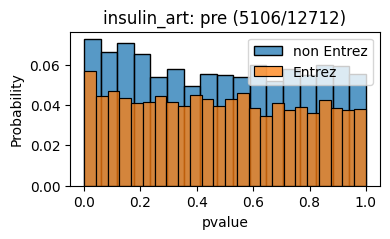

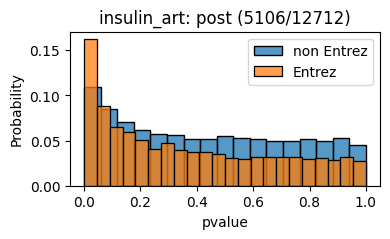

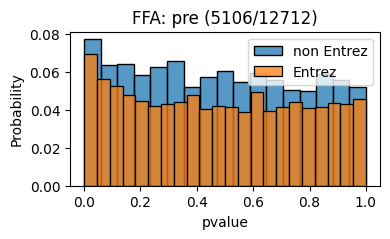

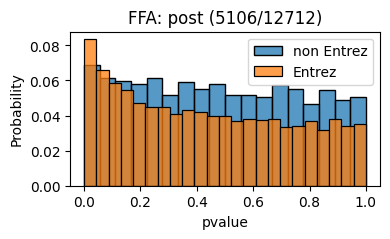

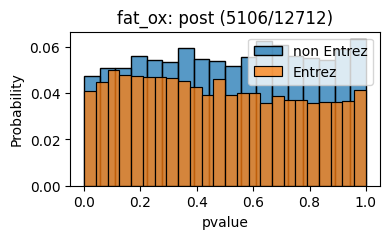

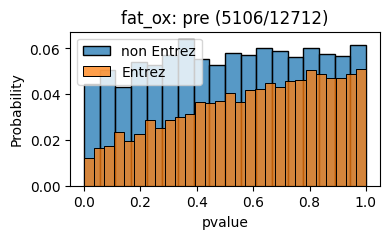

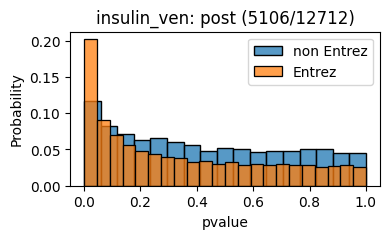

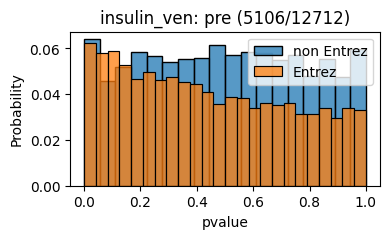

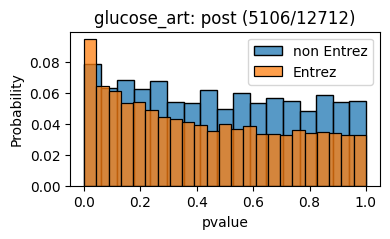

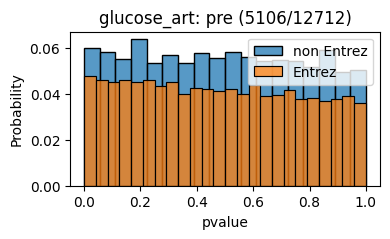

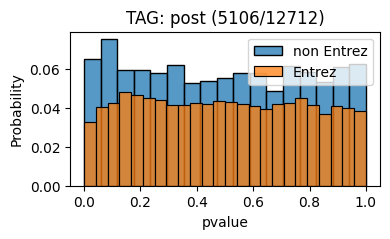

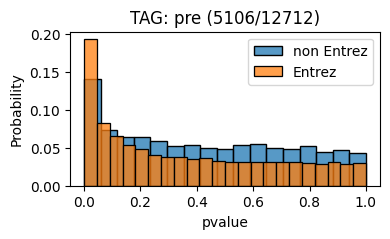

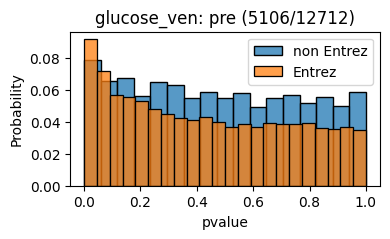

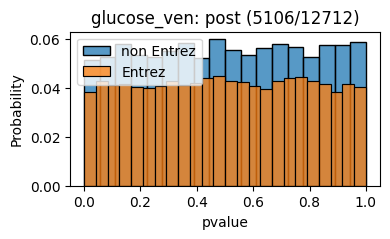

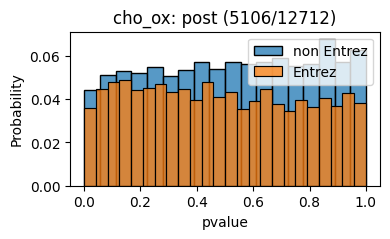

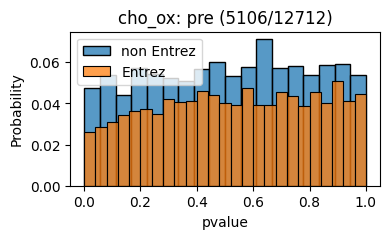

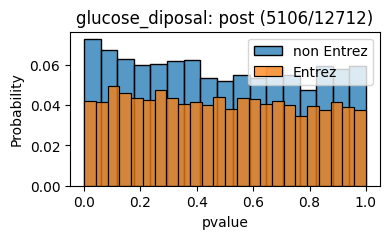

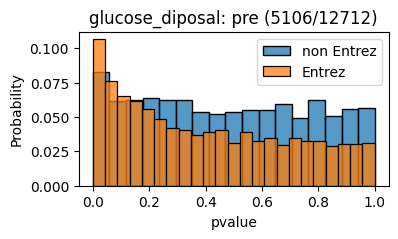

In [16]:
gene_id = "converted_alias"

for pheno, tmp_pheno_cors in cors.items():
    for tmp, pheno_cors in tmp_pheno_cors.items():

        pheno_cors_non_entrez = pheno_cors.loc[pheno_cors[gene_id].isna(),:]
        pheno_cors_entrez = pheno_cors.loc[~pheno_cors[gene_id].isna(),:]

        fig, ax = plt.subplots(figsize=(4, 2))
        sns.histplot(pheno_cors_non_entrez, x="pvalue", label="non Entrez", ax=ax, common_norm=False, stat="probability")
        sns.histplot(pheno_cors_entrez, x="pvalue", label="Entrez", ax=ax, common_norm=False, stat="probability")
        ax.set_title(f"{pheno}: {tmp} ({pheno_cors_non_entrez.shape[0]}/{pheno_cors_entrez.shape[0]})")
        plt.legend()

        plt.show()

## Geseca results

In [73]:
genesets.keys()

dict_keys(['wiki', 'reactome', 'GOBP', 'GOCC', 'KEGG', 'GOMF'])

In [71]:
geseca_fps = glob.glob("/Users/willtrim/Documents/projs/bedrest/outputs/geseca/*.csv")

In [4]:
pre = pd.read_csv(os.path.join(INPUT_DIR, "bp_pre.csv"))
post = pd.read_csv(os.path.join(INPUT_DIR, "bp_post.csv"))
both = pd.read_csv(os.path.join(INPUT_DIR, "bp.csv"))

In [74]:
geseca_results = {}

db_names = {
    "bp": "GOBP",
    "cc": "GOCC",
    "mf": "GOMF",
    "hallmark": "hallmark",
    "kegg": "KEGG",
    "reactome": "reactome",
    "wiki": "wiki"
}

for geseca_fp in geseca_fps:

    res_name = os.path.basename(geseca_fp).split(".")[0]
    db = db_names[res_name.split("_")[0]]

    is_pre = res_name.endswith("pre")
    is_post = res_name.endswith("post")
    
    if is_pre:
        res_type = "pre"
    elif is_post:
        res_type = "post"
    else:
        res_type = "both"
        
    db_geseca_res = pd.read_csv(geseca_fp)
    
    if db in geseca_results:
        geseca_results[db][res_type] = db_geseca_res
    else:
        geseca_results[db] = {res_type: db_geseca_res}
    


In [81]:
pval_threshold = 0.05


for db, db_res in geseca_results.items():
    pre = db_res["pre"]
    post = db_res["post"]
    
    pre_post = pd.merge(pre, post, on="pathway", suffixes=("_pre", "_post"), how="outer")
    # print(pre_post.shape)
    # pre_post = pd.merge(pre_post, both, on="pathway", how="outer")
    # print(pre_post.shape)

    pre_post = pre_post.loc[(pre_post.padj_pre < pval_threshold) | (pre_post.padj_post < pval_threshold),:]
    
    col = f"<>{pval_threshold}"
    pre_post[col] = f">={pval_threshold}"
    pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), col] = f"pre<{pval_threshold}"
    pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"post<{pval_threshold}"
    pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"<{pval_threshold}"

    db_res["pre_post"] = pre_post

    print(f"{db}:\t{pre.shape[0]}\t->\t{pre_post.shape[0]}")


# col_both = f"both<>{pval_threshold}"
# pre_post[col_both] = f"<{pval_threshold}"
# pre_post.loc[pre_post.padj >= pval_threshold, col_both] = f"both>={pval_threshold}"

GOBP:	3900	->	1462
wiki:	603	->	266
GOCC:	488	->	155
hallmark:	50	->	37
KEGG:	339	->	206
GOMF:	759	->	228
reactome:	1074	->	337


## Phenotypes

In [35]:
pheno = pd.read_csv("/Users/willtrim/Documents/projs/bedrest/outputs/BedRest_blood_phenotype.csv")
pheno.head()

,Participant ID,Group,Time Point,Venous Glucose (mmol/L),Venous Insulin (mU/L),Art. Glucose (mmol/L),Fat ox/kg,cho ox/Kg,FFA (mmol/L),TAG (mmol/L),Art. Insulin (mIU/L),Glucose Disposal,Post clamp Fat ox/kg,Post clamp cho ox/Kg
0,A1,Cocktail,Pre Bed Rest,4.8840,2.8600,4.30,1.887698,0.318964,0.415,0.58,4.70,8.520406,0.953146,2.791742
1,B1,Cocktail,Pre Bed Rest,4.8285,3.2250,4.16,1.321354,1.248777,0.390,0.46,5.90,6.175030,0.485657,3.534357
2,C1,Control,Pre Bed Rest,4.8840,7.1990,4.26,1.787597,0.315102,0.554,0.51,12.62,6.301969,0.875137,2.429926
3,D1,Control,Pre Bed Rest,4.9950,4.5270,4.63,1.950858,NaN,0.949,0.40,12.57,4.914221,1.068766,2.060187
4,E1,Control,Pre Bed Rest,4.6620,3.6575,4.45,1.391448,0.888337,0.427,1.24,19.94,5.444510,0.770687,2.182761


In [36]:
pheno["Clamp change Fat ox/kg"] = pheno["Post clamp Fat ox/kg"] - pheno["Fat ox/kg"]
pheno["Clamp change cho ox/kg"] = pheno["Post clamp cho ox/Kg"] - pheno["cho ox/Kg"]

### WB glucose and Hct

In [23]:
pheno1 = pd.read_csv("/Users/willtrim/Documents/projs/bedrest/outputs/Biological data Cocktail C1_LTBR MEDES 2017 English Version.csv", encoding='latin-1')
pheno2 = pd.read_csv("/Users/willtrim/Documents/projs/bedrest/outputs/Biological data Cocktail C2_LTBR MEDES 2017 English Version.csv", encoding='latin-1')

In [63]:
hcts = []
glucs = []

cols = ["Subject", "BDC-4", "HDT 60"]

for pheno_ in [pheno1, pheno2]:
    hcts.append(pheno_.loc[pheno_.Parameters == "Haematocrit", cols])
    glucs.append(pheno_.loc[pheno_.Parameters == "Glucose", cols])

In [64]:
hcts_df = pd.concat(hcts, axis=0)
glucs_df = pd.concat(glucs, axis=0)

In [65]:
hcts_df_ = pd.melt(hcts_df, id_vars="Subject", value_vars=cols[1:], value_name="Hct", var_name="Time Point")
glucs_df_ = pd.melt(glucs_df, id_vars="Subject", value_vars=cols[1:], value_name="Venous Glucose WB (g/L)", var_name="Time Point")

In [66]:
tmp_col = "Time Point"
for df in [hcts_df_, glucs_df_]:
    df.rename(columns={"Subject": "Participant ID"}, inplace=True, )
    df.loc[df[tmp_col] == "BDC-4", tmp_col] = "Pre Bed Rest"
    df.loc[df[tmp_col] == "HDT 49", tmp_col] = "Post Bed Rest"

In [69]:
cols = ["Participant ID", tmp_col]
pheno = pd.merge(pheno, hcts_df_, left_on = cols, right_on = cols)
pheno = pd.merge(pheno, glucs_df_, left_on = cols, right_on = cols)
pheno.head()

,Participant ID,Group,Time Point,Venous Glucose (mmol/L),Venous Insulin (mU/L),Art. Glucose (mmol/L),Fat ox/kg,cho ox/Kg,FFA (mmol/L),TAG (mmol/L),Art. Insulin (mIU/L),Glucose Disposal,Hct,Venous Glucose WB (g/L)
0,A1,Cocktail,Pre Bed Rest,4.8840,7.1990,4.30,1.887698,0.318964,0.415,0.58,4.70,7.820128,39.4,0.88
1,B1,Cocktail,Pre Bed Rest,4.8285,4.5270,4.16,1.321354,1.248777,0.390,0.46,5.90,6.683051,39.2,0.87
2,C1,Control,Pre Bed Rest,4.8840,3.6575,4.26,1.787597,0.315102,0.554,0.51,12.62,7.110272,43.2,0.88
3,D1,Control,Pre Bed Rest,4.9950,4.2795,4.63,1.950858,NaN,0.949,0.40,12.57,9.998550,39.2,0.9
4,E1,Control,Pre Bed Rest,4.6620,3.0645,4.45,1.391448,0.888337,0.427,1.24,19.94,8.058199,38.1,0.84


#### Venous Glucose WB vs Plasma concentrations

In [76]:
glucose_venous_plasma = "Venous Glucose (mmol/L)"
glucose_venous_wb = "Venous Glucose WB (g/L)"
hct = "Hct"

glucose_g_mol = 180.16

glucose_venous_plasma2WB = "Venous Glucose Plasma to WB (mmol/L)"
glucose_venous_wb_mmoll = "Venous Glucose WB (mmol/L)"


pheno[glucose_venous_plasma2WB] = pheno[glucose_venous_plasma].astype(float) * (1 - pheno[hct].astype(float) / 100)
pheno[glucose_venous_wb_mmoll] = pheno[glucose_venous_wb].astype(float) / glucose_g_mol * 1000

In [77]:
pheno.head()

,Participant ID,Group,Time Point,Venous Glucose (mmol/L),Venous Insulin (mU/L),Art. Glucose (mmol/L),Fat ox/kg,cho ox/Kg,FFA (mmol/L),TAG (mmol/L),Art. Insulin (mIU/L),Glucose Disposal,Hct,Venous Glucose WB (g/L),Venous Glucose Plasma to WB (mmol/L),Venous Glucose WB (mmol/L)
0,A1,Cocktail,Pre Bed Rest,4.8840,7.1990,4.30,1.887698,0.318964,0.415,0.58,4.70,7.820128,39.4,0.88,2.959704,4.884547
1,B1,Cocktail,Pre Bed Rest,4.8285,4.5270,4.16,1.321354,1.248777,0.390,0.46,5.90,6.683051,39.2,0.87,2.935728,4.829041
2,C1,Control,Pre Bed Rest,4.8840,3.6575,4.26,1.787597,0.315102,0.554,0.51,12.62,7.110272,43.2,0.88,2.774112,4.884547
3,D1,Control,Pre Bed Rest,4.9950,4.2795,4.63,1.950858,NaN,0.949,0.40,12.57,9.998550,39.2,0.9,3.036960,4.995560
4,E1,Control,Pre Bed Rest,4.6620,3.0645,4.45,1.391448,0.888337,0.427,1.24,19.94,8.058199,38.1,0.84,2.885778,4.662522


<Axes: xlabel='Venous Glucose WB (mmol/L)', ylabel='Venous Glucose (mmol/L)'>

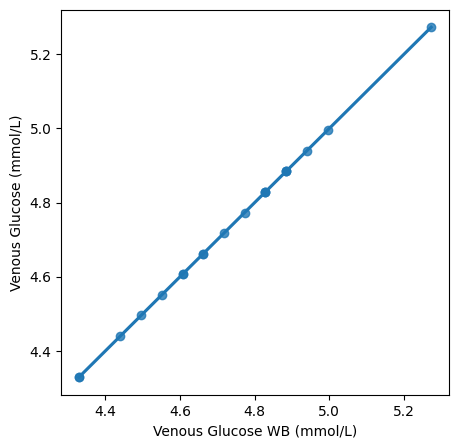

In [80]:
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(pheno, x=glucose_venous_wb_mmoll, y=glucose_venous_plasma, ax=ax)

In [22]:
pheno["insulin_AV"] = pheno["Art. Insulin (mIU/L)"] - pheno["Venous Insulin (mU/L)"]
pheno["glucose_AV"] = pheno["Art. Glucose (mmol/L)"] - pheno["Venous Glucose (mmol/L)"]

In [56]:
pheno_n = 13
pheno_names = pheno.columns[-pheno_n:]
pheno_names

Index(['Venous Glucose (mmol/L)', 'Venous Insulin (mU/L)',
       'Art. Glucose (mmol/L)', 'Fat ox/kg', 'cho ox/Kg', 'FFA (mmol/L)',
       'TAG (mmol/L)', 'Art. Insulin (mIU/L)', 'Glucose Disposal ',
       'Post clamp Fat ox/kg', 'Post clamp cho ox/Kg',
       'Clamp change Fat ox/kg', 'Clamp change cho ox/kg'],
      dtype='object')

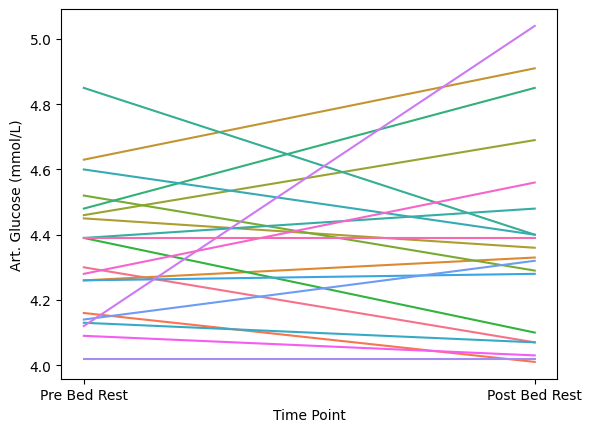

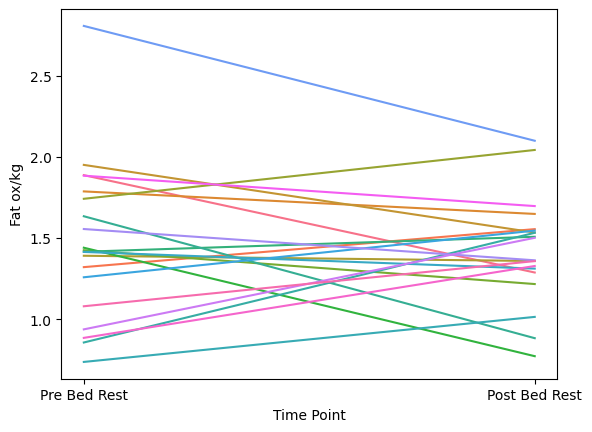

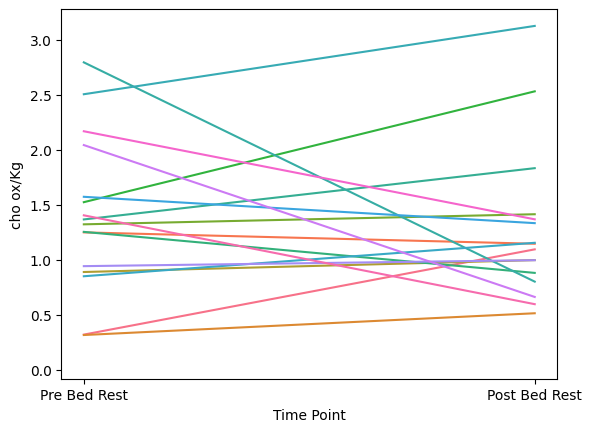

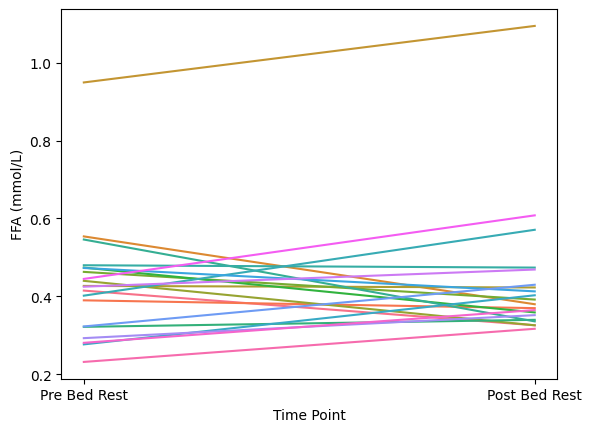

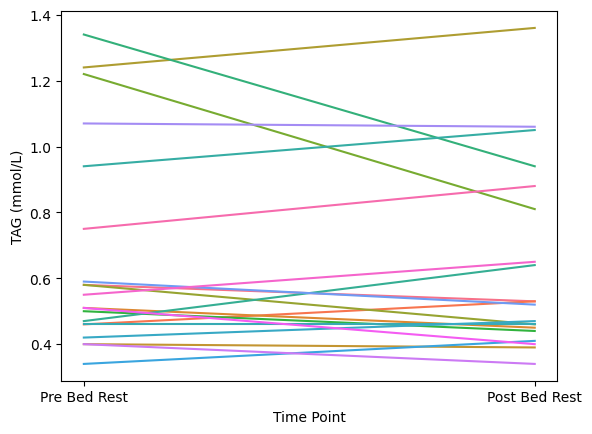

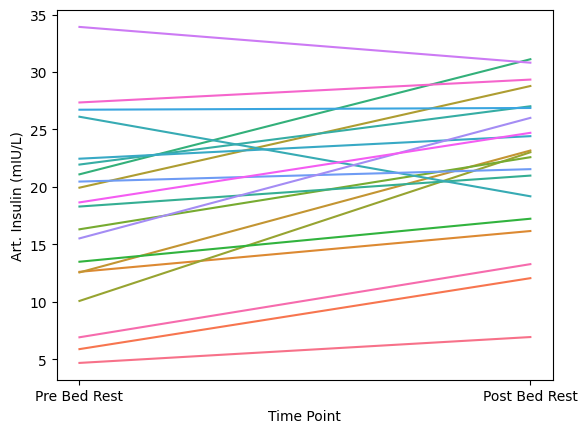

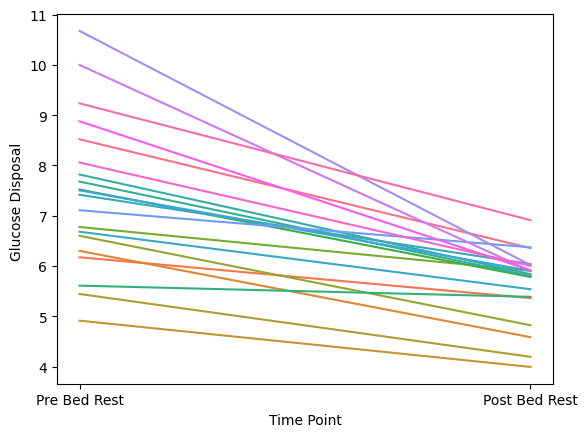

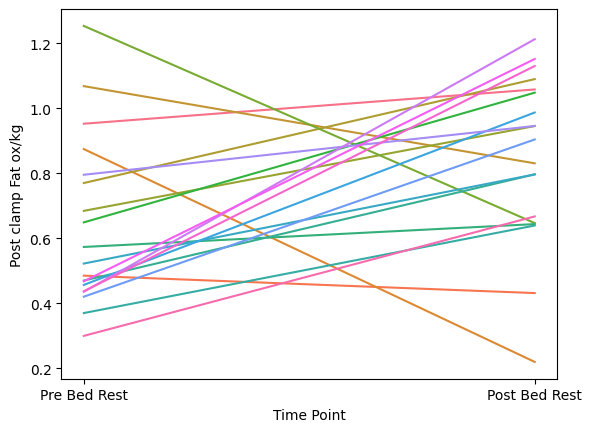

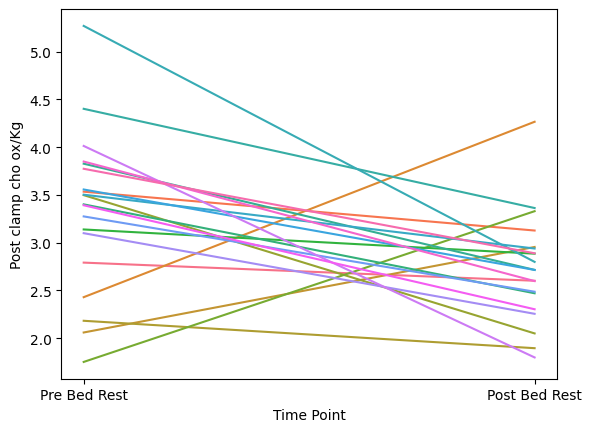

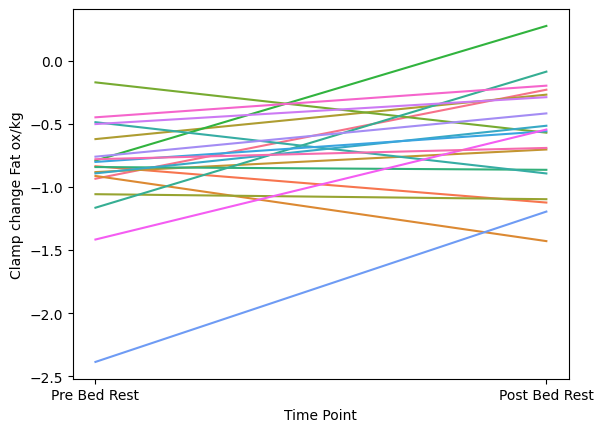

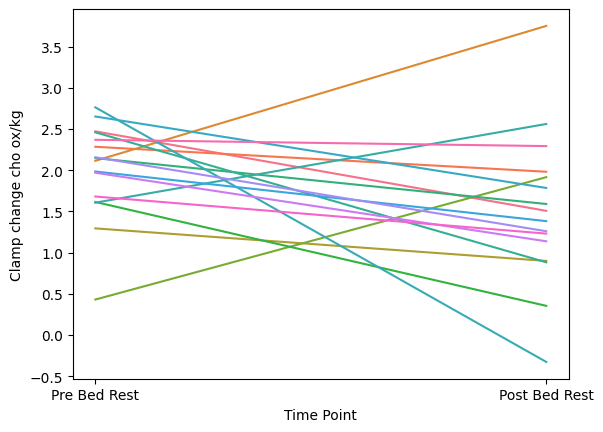

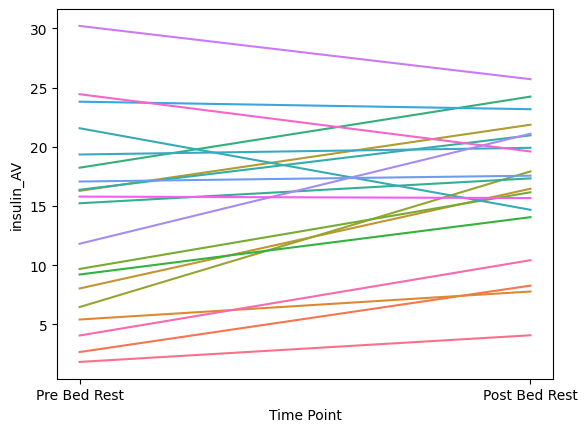

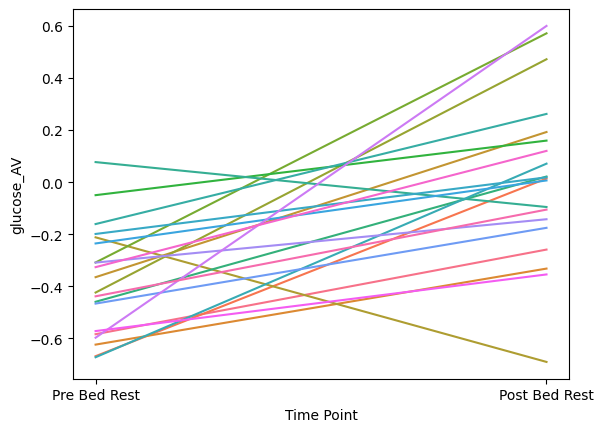

In [24]:
tmp_col = "Time Point"
pre_tmp = "Pre Bed Rest"
post_tmp = "Post Bed Rest"
participant_col = "Participant ID"


for pheno_name in pheno_names:
    pheno_pre = pheno.loc[pheno[tmp_col] == pre_tmp, [participant_col, tmp_col, pheno_name]]
    pheno_post = pheno.loc[pheno[tmp_col] == post_tmp, [participant_col, tmp_col, pheno_name]]

    pheno_concat = pd.concat([pheno_pre, pheno_post], axis=0)

    sns.lineplot(pheno_concat, x=tmp_col, y=pheno_name, hue=participant_col, legend=None)
    plt.show()

In [828]:
pheno.columns

Index(['Participant ID', 'Group', 'Time Point', 'Venous Glucose (mmol/L)',
       'Venous Insulin (mU/L)', 'Art. Glucose (mmol/L)', 'Fat ox/kg',
       'cho ox/Kg', 'FFA (mmol/L)', 'TAG (mmol/L)', 'Art. Insulin (mIU/L)',
       'Glucose Disposal ', 'insulin_AV', 'glucose_AV'],
      dtype='object')

In [833]:
glucose_cols = ["Art. Glucose (mmol/L)", "Venous Glucose (mmol/L)"]
part_id_cols = ["Participant ID", "Time Point"]
glucoses = pd.melt(pheno[part_id_cols + glucose_cols], id_vars = part_id_cols, value_vars=glucose_cols)

In [836]:
glucoses["measurement"] = glucoses[part_id_cols[0]] + "_" + glucoses[part_id_cols[1]]

<Axes: xlabel='variable', ylabel='value'>

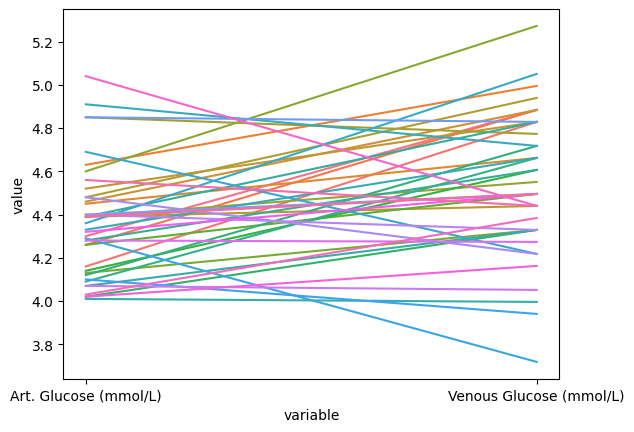

In [839]:
sns.lineplot(glucoses, x="variable", y="value", hue="measurement", legend=None)
# plt.legend(None)

<Axes: >

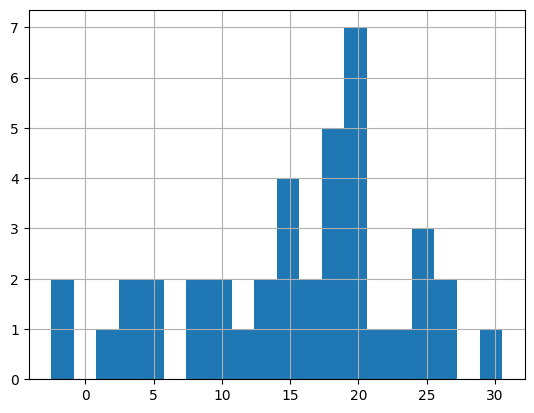

In [827]:
pheno["insulin_AV"].hist(bins=20)

In [60]:
pheno_n = len(pheno_names)

pheno_pre = pheno.loc[pheno[tmp_col] == pre_tmp, :].set_index(participant_col).iloc[:,-pheno_n:]
pheno_post = pheno.loc[pheno[tmp_col] == post_tmp, :].set_index(participant_col).iloc[:,-pheno_n:]

In [61]:
pheno_pre_post = pheno_post - pheno_pre

In [38]:
ebv = pd.read_csv("/Users/willtrim/Documents/projs/bedrest/outputs/bedrest_EBV.csv").set_index("Participant ID")
ebv.head()

,EBV_ratio
Participant ID,
A1,1.269584
B1,1.060012
C1,1.137112
D1,1.406753
E1,1.000000


In [43]:
pheno_pre_post = pd.concat([pheno_pre_post, ebv], axis=1)

In [62]:
pheno_pre_post

,Venous Glucose (mmol/L),Venous Insulin (mU/L),Art. Glucose (mmol/L),Fat ox/kg,cho ox/Kg,FFA (mmol/L),TAG (mmol/L),Art. Insulin (mIU/L),Glucose Disposal,Post clamp Fat ox/kg,Post clamp cho ox/Kg,Clamp change Fat ox/kg,Clamp change cho ox/kg
Participant ID,,,,,,,,,,,,,
A1,-0.5550,0.0000,-0.23,-0.599451,0.775379,-0.089,-0.05,2.25,-2.163963,0.105380,-0.189900,0.704831,-0.965279
B1,-0.8325,0.5620,-0.15,0.234004,-0.103375,-0.020,0.07,6.17,-0.812882,-0.053633,-0.406724,-0.287636,-0.303350
C1,-0.2220,1.1860,0.07,-0.138607,0.197983,-0.174,-0.06,3.55,-1.715805,-0.654934,1.836412,-0.516327,1.638430
D1,-0.2775,2.1785,0.28,-0.416447,NaN,0.145,-0.01,10.60,-0.919772,-0.237527,0.895220,0.178920,NaN
E1,0.3885,3.2525,-0.09,-0.032341,0.108151,-0.004,0.12,8.84,-1.248959,0.319719,-0.286878,0.352060,-0.395029
F1,-0.6660,1.4730,0.23,0.300594,NaN,-0.114,-0.12,12.93,-1.778510,0.260952,-1.447639,-0.039643,NaN
G1,-1.1100,-0.2055,-0.23,-0.208299,0.091835,-0.071,-0.41,6.27,-0.869504,-0.606674,1.578057,-0.398374,1.486222
H1,-0.4995,-1.1030,-0.29,-0.667792,1.008229,-0.115,-0.06,3.74,-1.739048,0.399080,-0.253603,1.066872,-1.261832
I1,-0.1110,4.0060,0.37,0.092334,-0.373192,0.018,-0.40,10.01,-0.222282,0.070366,-0.930778,-0.021969,-0.557585


In [66]:
cols = ['Venous Glucose (mmol/L)', 'Art. Glucose (mmol/L)', 'Venous Insulin (mU/L)', 'Art. Insulin (mIU/L)', 
        'FFA (mmol/L)', 'TAG (mmol/L)',
       'Glucose Disposal ',  'Fat ox/kg',
       'cho ox/Kg', 'Post clamp Fat ox/kg', 'Post clamp cho ox/Kg'
       ]
col_names = ['Venous Glucose (mmol/L)', 'Art. Glucose (mmol/L)', 'Venous Insulin (mU/L)', 'Art. Insulin (mIU/L)', 
        'FFA (mmol/L)', 'TAG (mmol/L)',
       'Glucose Disposal',  'WB Fat ox pre HEIC',
       'WB CHO ox pre HEIC', 'WB Fat ox post HEIC', 'WB CHO ox post HEIC'
       ]
pheno_pre_post_ = pheno_pre_post[cols]
pheno_pre_post_.columns = col_names

In [67]:
pheno_names = pheno_pre_post_.columns

In [68]:
phenotype_cor = np.eye(len(pheno_names))
phenotype_cor_pval = np.zeros((len(pheno_names), len(pheno_names)))

for i, col1 in enumerate(pheno_names):
    
    phen1 = pheno_pre_post_[col1]
    phen1_na = phen1.isna()
    
    for j in range(i):
        
        phen2 = pheno_pre_post_[pheno_names[j]]
        phen2_na = phen2.isna()
        idx = ~(phen1_na | phen2_na)
        cor = scipy.stats.spearmanr(phen1.loc[idx], phen2.loc[idx])
        phenotype_cor[i, j] = cor.statistic
        phenotype_cor[j, i] = cor.statistic
        phenotype_cor_pval[i, j] = cor.pvalue
        phenotype_cor_pval[j, i] = cor.pvalue

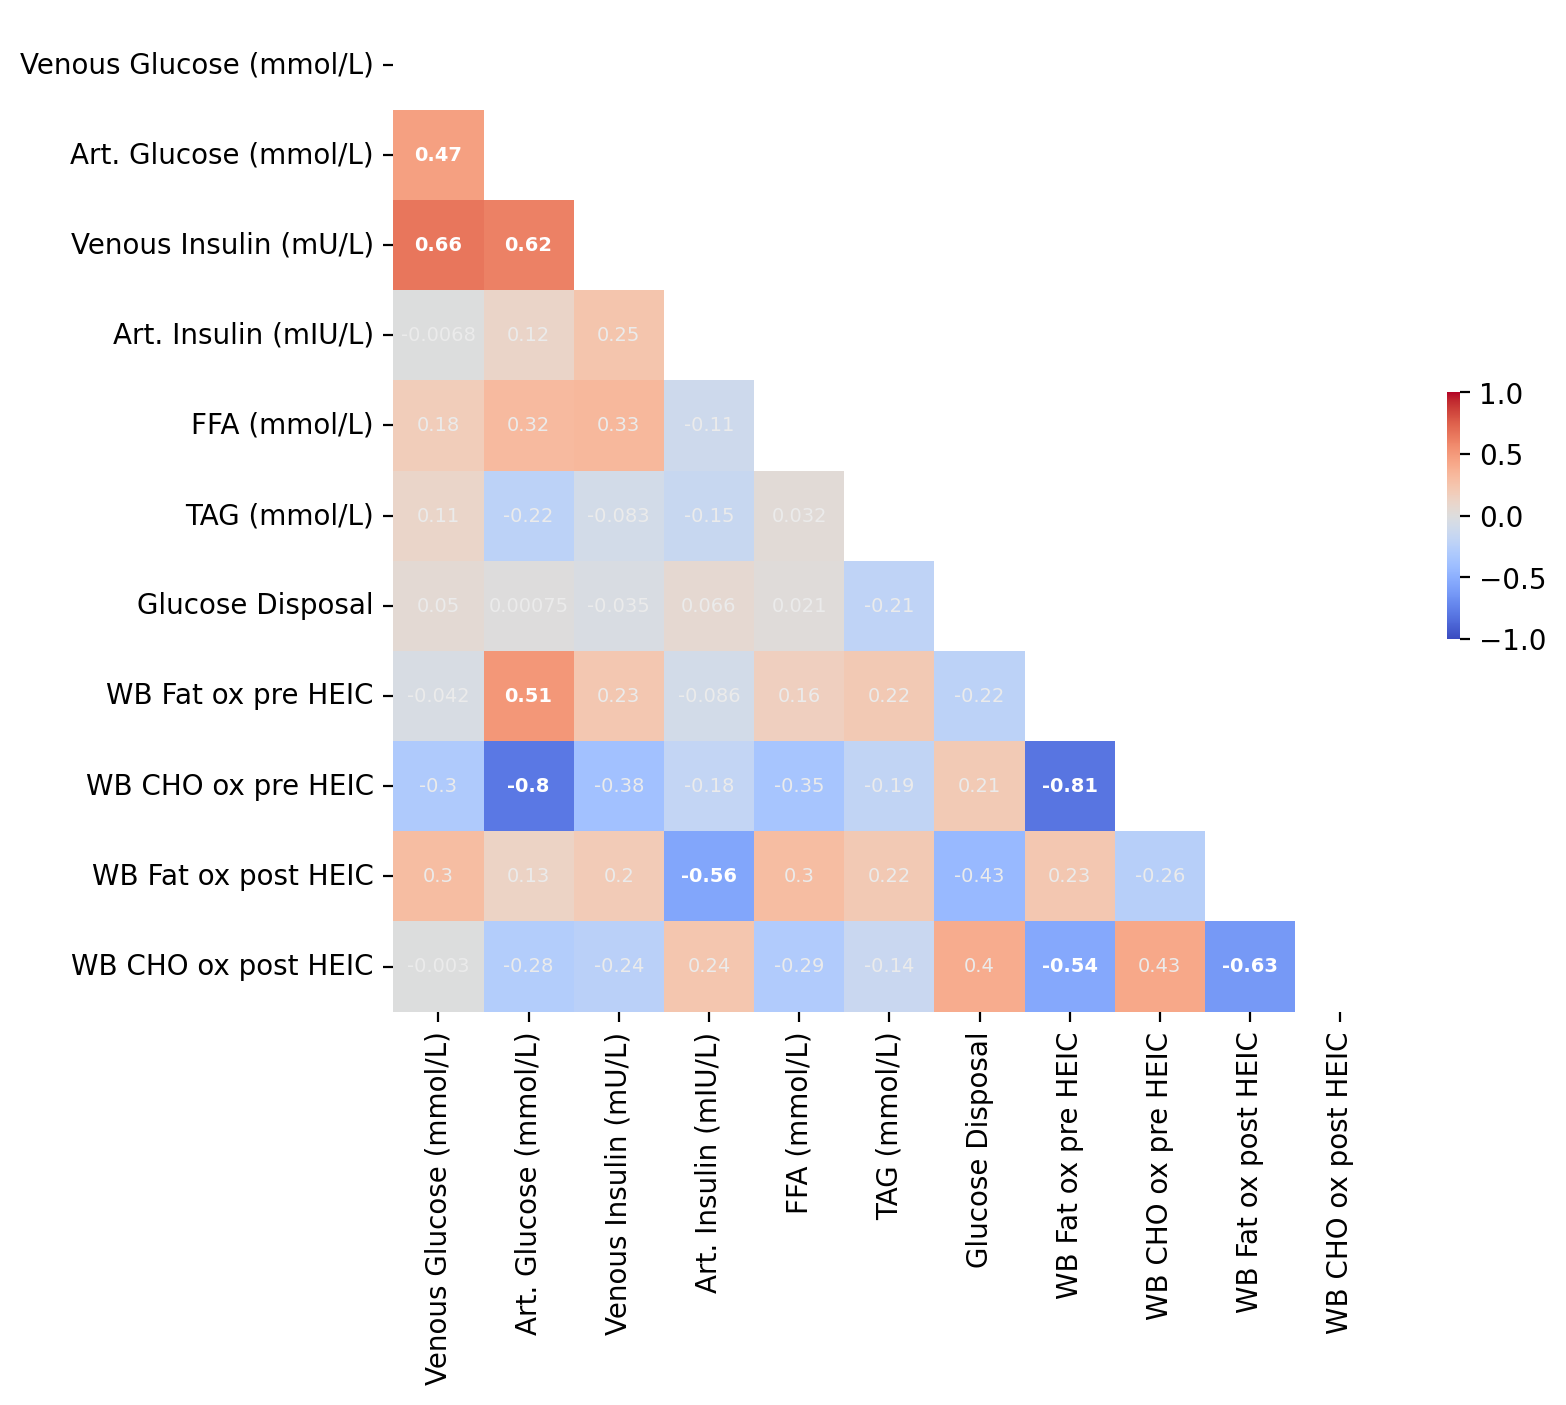

In [75]:
mask = np.triu(np.ones_like(phenotype_cor, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

sns.heatmap(
    phenotype_cor,
    square=True,
    cmap="coolwarm",
    xticklabels=pheno_names,
    yticklabels=pheno_names,
    annot=phenotype_cor,
    annot_kws={"fontsize": 6, "color": "#ebebeb"}, 
    mask=mask,
    ax=ax,
    cbar_kws={"shrink": 0.2, 'location': 'right'},
    vmax=1,
    vmin=-1
)

significance_mask = phenotype_cor_pval < 0.05

i = 1
j = 0
for k, text in enumerate(ax.texts):
    text.set_fontsize(7)
    
    if significance_mask[i, j]:
        text.set_weight('bold')
        text.set_color('white')
    j += 1 
    if j == i:
        i += 1
        j = 0

In [461]:
hls = {}

# Test pre vs post

In [593]:
test_res = {}
gene_id = "converted_alias"


for db, db_genesets in genesets.items():

    db_res = {}
    
    for pheno, pheno_cors in cors.items():

        pvals = {}
        r_difs = {}
        
        pre = pheno_cors["pre"]
        post = pheno_cors["post"]
    
        for geneset_name, geneset in db_genesets.pathways.items():
            
            r_pre = pre.loc[pre[gene_id].isin(geneset), "r"].values
            r_post = post.loc[post[gene_id].isin(geneset), "r"].values
        
            r_pre_med = np.nanmedian(r_pre)
            r_post_med = np.nanmedian(r_post)

            r_dif = r_post_med - r_pre_med

            pval = scipy.stats.mannwhitneyu(r_pre, r_post, nan_policy="omit").pvalue

            pvals[geneset_name] = pval
            r_difs[geneset_name] = r_dif
            
        
        db_res[pheno] = {
            "pvals": pd.Series(pvals),
            "r_difs": pd.Series(r_difs)
        }
            
    pval_dict = {pheno: pheno_res["pvals"] for pheno, pheno_res in db_res.items()}
    r_dif_dict = {pheno: pheno_res["r_difs"] for pheno, pheno_res in db_res.items()}

    pvals_df = pd.DataFrame.from_dict(pval_dict)
    r_difs_df = pd.DataFrame.from_dict(r_dif_dict)
    
    test_res[db] = {
        "pvals": pvals_df,
        "r_difs": r_difs_df,
        "r_difs_abs": r_difs_df.abs()
    }

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_41540/2606644110.py:27: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  pval = scipy.stats.mannwhitneyu(r_pre, r_post, nan_policy="omit").pvalue


In [594]:
for db, db_genesets in genesets.items():

    pvals = test_res[db]["pvals"]
    padj = {}
    for col in pvals.columns:
        padj[col] = multipletests(pvals[col], method="holm")[1]
        
    padj_df = pd.DataFrame.from_dict(padj)
    padj_df.index = pvals.index
    
    test_res[db]["padj"] = padj_df

## Dotplotting

In [365]:
adatas = {}

for db in genesets.keys():
    pvals_df = test_res[db]["padj"]
    
    
    r_dif_df = test_res[db]["r_difs"]
    sign_df = r_dif_df > 0
    
    
    pvals_df_ = -np.log10(pvals_df)
    pvals_df_[~sign_df] = -pvals_df_[~sign_df]
    
    
    
    adata = ad.AnnData(pvals_df_.values)
    
    adata.var_names = pvals_df_.columns
    adata.obs_names = pvals_df_.index
    
    adata.obs["pathway"] = pd.Categorical(adata.obs_names)
    adata.obs.index.rename("index", inplace=True)
    
    
    # signif
    mu_pval_threshold = 0.05
    adata.obs["any_signif"] = (pvals_df < mu_pval_threshold).any(axis=1)
    
    # geseca signif
    geseca_pval_threshold = 0.05
    db_geseca_res_pre = geseca_results[db]["pre"]
    db_geseca_res_post = geseca_results[db]["post"]

    idx = adata.obs_names.isin(db_geseca_res_pre.pathway)
    adata.obs["geseca_pre_padj"] = np.nan
    adata.obs.loc[idx, "geseca_pre_padj"] = db_geseca_res_pre.set_index("pathway").loc[adata.obs_names[idx], "padj"].values
    adata.obs["geseca_signif_pre"] = adata.obs["geseca_pre_padj"] < geseca_pval_threshold
    
    idx = adata.obs_names.isin(db_geseca_res_post.pathway)
    adata.obs["geseca_post_padj"] = np.nan
    adata.obs.loc[idx, "geseca_post_padj"] = db_geseca_res_post.set_index("pathway").loc[adata.obs_names[idx], "padj"].values
    adata.obs["geseca_signif_post"] = adata.obs["geseca_post_padj"] < geseca_pval_threshold
    
    # adata.obs["geseca_post_padj"] = db_geseca_res_post.set_index("pathway").loc[adata.obs_names, "padj"]
    
    # adata.obs["geseca_signif_post"] = adata.obs["geseca_post_padj"] < geseca_pval_threshold
    

    adatas[db] = adata

In [494]:
adatas_hl = {}
r_difs_abs_hl = {}

### KEGG

In [409]:
db = "KEGG"

adata = adatas[db].copy()
r_difs_abs = test_res[db]["r_difs_abs"].loc[adata.obs_names,:].copy()

markers = ['glucose_art', 'glucose_ven', 'cho_ox', 'insulin_art', 'insulin_ven', 'glucose_diposal', 'TAG', 'FFA', 'fat_ox']

In [410]:
pvals_df = test_res[db]["padj"]

assert (pvals_df.index == adata.obs_names).all()
assert (pvals_df.columns == adata.var_names).all()


assert (r_difs_abs.index == adata.obs_names).all()
assert (r_difs_abs.columns == adata.var_names).all()


r_difs_abs[pvals_df > mu_pval_threshold] = 0

In [412]:
# adata.obs = adata.obs.sort_index()

r_difs_abs = r_difs_abs.loc[adata.obs_names,:]

idx = adata.obs.any_signif | adata.obs.geseca_signif_pre | adata.obs.geseca_signif_post
adata_ = adata[idx,:]
r_difs_abs_ = r_difs_abs.loc[idx,:]

In [414]:
adata.shape, adata_.shape

((369, 9), (303, 9))

In [379]:
bs = 103
save_fig = True

assert (adata_.obs_names == r_difs_abs_.index).all()

for i in range(0, adata_.shape[0], bs):
    p = dotplot(
        adata_[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=-5, #np.nanmin(adata.X),
        vmax=5, #np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=r_difs_abs_.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True,
        colorbar_title="-log10(p_adj)",
        size_title="~ Median R (post - pre)"
    ) #, dendrogram=True)

    # p.size_exponent=1
    p.grid=True
    p.group_cmaps = None
    p.make_figure()
    
    if save_fig:
        plt.savefig(f'figures_cors/{db}_{i}.png', bbox_inches='tight')
        plt.close()

In [556]:
hls["KEGG"] = pd.Series([gs.replace(".", "").strip(".").strip("-").strip() for gs in """-2-Oxocarboxylic acid metabolism
Cell cycle
Citrate cycle (TCA cycle)
ErbB signaling pathway
Fatty acid metabolism
FoxO signaling pathway
Glutathione metabolism
Glycolysis / Gluconeogenesis -
Inositol phosphate metabolism
MAPK signaling pathway .
NF-kappa B signaling pathway -
Oxidative phosphorylation -
PPAR signaling pathway
Pentose phosphate pathway -
Phosphatidylinositol signaling system
Phospholipase D signaling pathway -
Proteasome
Protein export
Rap1 signaling pathway
Ras signaling pathway
Ribosome
Spliceosome
Ubiquitin mediated proteolysis
Valine, leucine and isoleucine degradation
cAMP signaling pathway
-cGMP-PKG signaling pathway
- AGE-RAGE signaling pathway in diabetic complications
AMPK signaling pathway
Adipocytokine signaling pathway
Antigen processing and presentation -
Apoptosis
-Axon guidance
- B cell receptor signaling pathway
Complement and coagulation cascades
- Fc gamma R-mediated phagocytosis .
Glucagon signaling pathway
Hippo signaling pathway -
Insulin resistance -
Insulin signaling pathway -
JAK-STAT signaling pathway -
Non-alcoholic fatty liver disease
-Notch signaling pathway.
PI3K-Akt signaling pathway -
Peroxisome
Protein processing in endoplasmic reticulum
-T cell receptor signaling pathway -
TGF-beta signaling pathway -
-TNF signaling pathway
Thermogenesis
Wnt signaling pathway -
mTOR signaling pathway -
Lipid and atherosclerosis""".split("\n")])

In [557]:
hls["KEGG"].loc[~hls["KEGG"].isin(adatas["KEGG"].obs_names)]

Series([], dtype: object)

### GOBP

In [688]:
db = "GOBP"

adata = adatas[db].copy()
r_difs_abs = test_res[db]["r_difs_abs"].loc[adata.obs_names,:].copy()

markers = ['glucose_art', 'glucose_ven', 'cho_ox', 'insulin_art', 'insulin_ven', 'glucose_diposal', 'TAG', 'FFA', 'fat_ox']

In [689]:
pvals_df = test_res[db]["padj"]

assert (pvals_df.index == adata.obs_names).all()
assert (pvals_df.columns == adata.var_names).all()


assert (r_difs_abs.index == adata.obs_names).all()
assert (r_difs_abs.columns == adata.var_names).all()


r_difs_abs[pvals_df > mu_pval_threshold] = 0

In [690]:
# adata.obs = adata.obs.sort_index()

r_difs_abs = r_difs_abs.loc[adata.obs_names,:]

idx = adata.obs.any_signif | adata.obs.geseca_signif_pre | adata.obs.geseca_signif_post
adata_ = adata[idx,:]
r_difs_abs_ = r_difs_abs.loc[idx,:]

In [691]:
adata.shape, adata_.shape

((7583, 9), (2525, 9))

In [ ]:
bs = 105
save_fig = True

assert (adata_.obs_names == r_difs_abs_.index).all()

for i in range(0, adata_.shape[0], bs):
    p = dotplot(
        adata_[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=-5, #np.nanmin(adata.X),
        vmax=5, #np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=r_difs_abs_.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True,
        colorbar_title="-log10(p_adj)",
        size_title="~ Median R (post - pre)"
    ) #, dendrogram=True)

    # p.size_exponent=1
    p.grid=True
    p.group_cmaps = None
    p.make_figure()
    
    if save_fig:
        plt.savefig(f'figures_cors/{db}_{i}.png', bbox_inches='tight')
        plt.close()

In [693]:
hls["GOBP"] = pd.Series(list({gs.replace("-", "").strip().replace(" ", "_") for gs in """GOBP_ACTIVATION_OF_IMMUNE_RESPONSE
GOBP_ACTIVATION_OF_INNATE_IMMUNE_RESPONSE
GOBP_ACYL_COA_METABOLIC_PROCESS
- GOBP_ADAPTIVE_IMMUNE_RESPONSE
- GOBP_ADIPOSE_TISSUE_DEVELOPMENT
GOBP_AEROBIC_RESPIRATION
GOBP_ALPHA_BETA_T_CELL_ACTIVATION
GOBP_AMINO_ACID_METABOLIC_PROCESS
-GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION
GOBP_APOPTOTIC PROCESS
GOBP_ATP_METABOLIC_PROCESS
GOBP_ATP_SYNTHESIS_COUPLED_ELECTRON_TRANSPORT
GOBP_B_CELL_ACTIVATION
GOBP_B_CELL_PROLIFERATION
GOBP_CANONICAL_NF_KAPPAB_SIGNAL_TRANSDUCTION
GOBP_CARBOHYDRATE_BIOSYNTHETIC_PROCESS
GOBP_CARBOHYDRATE_METABOLIC_PROCESS-
GOBP_CD4_POSITIVE_ALPHA_BETA_T_CELL_ACTIVATION
GOBP_CELLULAR_RESPIRATION
GOBP_CELLULAR_RESPONSE_TO_INSULIN_STIMULUS
GOBP_CELLULAR_RESPONSE_TO_LIPID
GOBP_CELLULAR_RESPONSE_TO_OXIDATIVE_STRESS
-GOBP_CELLULAR_RESPONSE_TO_REACTIVE_OXYGEN_SPECIES
GOBP CELL ACTIVATION
GOBP_CELL_CYCLE
GOBP_CELL_SURFACE_RECEPTOR_PROTEIN_SERINE_THREONINE_KINASE_SIGNALING_PATHWAY
GOBP_CELL_SURFACE_RECEPTOR_PROTEIN_TYROSINE_KINASE_SIGNALING_PATHWAY
GOBP_CHAPERONE_MEDIATED_PROTEIN_FOLDING
GOBP_CHROMATIN_REMODELING
GOBP_CYTOKINESIS
-GOBP_CYTOKINE_PRODUCTION
GOBP_CYTOPLASMIC_TRANSLATION
GOBP_ELECTRON_TRANSPORT_CHAIN
-GOBP_ERAD_PATHWAY
GOBP_ERBB_SIGNALING_PATHWAY -
GOBP_ERK1_AND_ERK2_CASCADE
GOBP_FATTY_ACID_BETA_OXIDATION
GOBP_FATTY_ACID_BIOSYNTHETIC_PROCESS
GOBP_FATTY_ACID_CATABOLIC_PROCESS
GOBP_FATTY_ACID_METABOLIC_PROCESS
GOBP_FAT_CELL_DIFFERENTIATION
GOBP_GLUCOSE_METABOLIC_PROCESS
GOBP_GLYCEROPHOSPHOLIPID_BIOSYNTHETIC_PROCESS
GOBP_GLYCOPROTEIN_BIOSYNTHETIC_PROCESS-
GOBP_GLYCOSYLATION
GOBP_IMPORT_INTO_THE_MITOCHONDRION
GOBP_INSULIN_RECEPTOR_SIGNALING_PATHWAY
-GOBP_INTERLEUKIN_10_PRODUCTION
GOBP_INTERLEUKIN_1_BETA_PRODUCTION -
GOBP_INTERLEUKIN_1_PRODUCTION
GOBP_INTERLEUKIN_6_PRODUCTION
GOBP_INTRACELLULAR_GLUCOSE_HOMEOSTASIS
-GOBP_INTRACELLULAR_LIPID_TRANSPORT
GOBP_INTRACELLULAR_PROTEIN_TRANSPORT
GOBP_LEUKOCYTE_DIFFERENTIATION
GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY
GOBP_LEUKOCYTE_MEDIATED_IMMUNITY
GOBP_LEUKOCYTE_PROLIFERATION
GOBP_LIPID_BIOSYNTHETIC PROCESS
GOBP_LIPID_CATABOLIC_PROCESS
GOBP_LIPID_HOMEOSTASIS
GOBP_LIPID_IMPORT_INTO_CELL
GOBP_LIPID_LOCALIZATION
GOBP_LIPID_METABOLIC_PROCESS
GOBP_LIPID_OXIDATION
GOBP_LONG_CHAIN_FATTY_ACID_METABOLIC_PROCESS -
GOBP_LONG_CHAIN_FATTY_ACYL_COA_BIOSYNTHETIC_PROCESS
GOBP_LYMPHOCYTE_ACTIVATION
GOBP_MAPK_CASCADE -
GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_CYTOCHROME_C_TO_OXYGEN
GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_NADH_TO_UBIQUINONE
GOBP_MITOCHONDRIAL_GENE_EXPRESSION
GOBP_MITOCHONDRIAL_RESPIRATORY_CHAIN_COMPLEX_ASSEMBLY
-GOBP_MITOTIC_CELL_CYCLE
GOBP_MONOCARBOXYLIC_ACID_CATABOLIC_PROCESS
GOBP_MYELOID_LEUKOCYTE_ACTIVATION-
-GOBP_NEURON_DEVELOPMENT
GOBP_OXIDATIVE_PHOSPHORYLATION
GOBP_PEROXISOME_ORGANIZATION
GOBP_PHOSPHATIDYLINOSITOL_BIOSYNTHETIC_PROCESS
GOBP_PROTEASOME_MEDIATED_UBIQUITIN_DEPENDENT_PROTEIN_CATABOLIC_PROCESS
-GOBP_REGULATION_OF_CELLULAR_RESPONSE_TO_INSULIN_STIMULUS
GOBP_REGULATION_OF_CELLULAR_RESPONSE_TO_STRESS
GOBP_REGULATION_OF_CELL_KILLING
GOBP_REGULATION_OF_D_GLUCOSE_TRANSMEMBRANE_TRANSPORT
-GOBP_REGULATION_OF_GLUCONEOGENESIS
GOBP_REGULATION_OF_IMMUNE_RESPONSE
-GOBP_REGULATION_OF_INSULIN_RECEPTOR_SIGNALING_PATHWAY
GOBP_REGULATION_OF_LIPID_LOCALIZATION
GOBP_REGULATION_OF_LIPID_METABOLIC_PROCESS
GOBP_REGULATION_OF_LIPID_TRANSPORT
GOBP_REGULATION_OF_PHOSPHORYLATION
GOBP_REGULATION_OF_POST_TRANSLATIONAL_PROTEIN_MODIFICATION
GOBP_REGULATION_OF_PROTEIN_METABOLIC_PROCESS
GOBP_REGULATION_OF_UBIQUITIN_DEPENDENT_PROTEIN_CATABOLIC_PROCESS
GOBP_RESPONSE_TO_INSULIN
GOBP_RESPONSE_TO_LIPID
GOBP_RESPONSE_TO_OXIDATIVE_STRESS
GOBP_RESPONSE_TO_REACTIVE_OXYGEN_SPECIES -
GOBP_RESPONSE_TO_TRANSFORMING_GROWTH_FACTOR_BETA -
GOBP_RESPONSE_TO_TUMOR_NECROSIS_FACTOR
GOBP_RESPONSE_TO_TYPE_II_INTERFERON
GOBP_RIBOSOME_BIOGENESIS
GOBP_RNA_MODIFICATION
GOBP_SPLICEOSOMAL_SNRNP_ASSEMBLY
GOBP_TRANSLATION
GOBP_TRANSLATIONAL_INITIATION
GOBP_TRICARBOXYLIC_ACID_CYCLE
GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS
GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_ENDOGENOUS_ANTIGEN
GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_OR_POLYSACCHARIDE_ANTIGEN_VIA_MHC_CLASS_II
GOBP_BRANCHED_CHAIN_AMINO_ACID_METABOLIC_PROCESS
GOBP_LONG_CHAIN_FATTY_ACYL_COA_BIOSYNTHETIC_PROCESS
GOBP_LONG_CHAIN_FATTY_ACYL_COA_METABOLIC_PROCESS
GOBP_LOW_DENSITY_LIPOPROTEIN_PARTICLE_CLEARANCE
GOBP_MACROPHAGE_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_MITOCHONDRIAL_RESPIRATORY_CHAIN_COMPLEX_ASSEMBLY
GOBP_MYELOID_CELL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_MYELOID_DENDRITIC_CELL_ACTIVATION
GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY
GOBP_CD8_POSITIVE_ALPHA_BETA_T_CELL_ACTIVATION
GOBP_DENDRITIC_CELL_ANTIGEN_PROCESSING_AND_PRESENTATION
GOBP_FC_GAMMA_RECEPTOR_SIGNALING_PATHWAY
GOBP_GAMMA_DELTA_T_CELL_ACTIVATION
GOBP_GLUTATHIONE_METABOLIC_PROCESS
GOBP_ENDOLYSOSOMAL_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY
GOBP_GRANULOCYTE_ACTIVATION
GOBP_LEUKOCYTE_MEDIATED_IMMUNITY
GOBP_GLYCOSAMINOGLYCAN_METABOLIC_PROCESS
GOBP_LIPID_CATABOLIC_PROCESS
GOBP_LIPID_EXPORT_FROM_CELL -
GOBP_LIPID_HOMEOSTASIS-
GOBP_LIPID_IMPORT_INTO_CELL
GOBP_LIPID_LOCALIZATION
GOBP_LIPID_MODIFICATION-
GOBP_LIPID_OXIDATION -
GOBP_LIPOPOLYSACCHARIDE_MEDIATED_SIGNALING_PATHWAY
GOBP_LONG_CHAIN_FATTY_ACYL_COA_BIOSYNTHETIC_PROCESS
GOBP_LOW_DENSITY_LIPOPROTEIN_PARTICLE_CLEARANCE
GOBP_LYMPHOCYTE_MEDIATED_IMMUNITY
GOBP_LYTIC_VACUOLE_ORGANIZATION
GOBP_MACROPHAGE_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_NEUTROPHIL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_NK_T_CELL_ACTIVATION
GOBP_PEPTIDE_ANTIGEN_ASSEMBLY_WITH_MHC_PROTEIN_COMPLEX
GOBP_REGULATION_OF_ANTIGEN_PROCESSING_AND_PRESENTATION
GOBP_REGULATION_OF_CD8_POSITIVE_ALPHA_BETA_T_CELL_ACTIVATION
GOBP_REGULATION_OF_FATTY_ACID_BETA_OXIDATION
GOBP_REGULATION_OF_PEPTIDASE_ACTIVITY
GOBP_REGULATION_OF_SUPEROXIDE_ANION_GENERATION
GOBP_REGULATION_OF_RELEASE_OF_CYTOCHROME_C_FROM_MITOCHONDRIA
GOBP_RESPIRATORY_BURST
GOBP_RESPONSE_TO_LECTIN
GOBP_RESPONSE_TO_LEPTIN
GOBP_RESPONSE_TO_HYDROGEN_PEROXIDE
GOBP_RESPONSE_TO_INSULIN
GOBP_SHORT_CHAIN_FATTY_ACID_METABOLIC_PROCESS
GOBP_SUPEROXIDE_ANION_GENERATION
GOBP_TOLL_LIKE_RECEPTOR_2_SIGNALING_PATHWAY
GOBP_TRIGLYCERIDE_METABOLIC_PROCESS""".split("\n")}))

In [694]:
hls["GOBP"].loc[~hls["GOBP"].isin(adatas["GOBP"].obs_names)]

Series([], dtype: object)

In [695]:
idx = adata_.obs_names.isin(hls[db])
adatas_hl[db] = adata_[idx,:].copy()
r_difs_abs_hl[db] = r_difs_abs_.loc[idx,:].copy()

assert (adatas_hl[db].obs_names == r_difs_abs_hl[db].index).all()

### Reactome

In [696]:
db = "reactome"

adata = adatas[db].copy()
r_difs_abs = test_res[db]["r_difs_abs"].loc[adata.obs_names,:].copy()

markers = ['glucose_art', 'glucose_ven', 'cho_ox', 'insulin_art', 'insulin_ven', 'glucose_diposal', 'TAG', 'FFA', 'fat_ox']

In [697]:
pvals_df = test_res[db]["padj"]

assert (pvals_df.index == adata.obs_names).all()
assert (pvals_df.columns == adata.var_names).all()


assert (r_difs_abs.index == adata.obs_names).all()
assert (r_difs_abs.columns == adata.var_names).all()


r_difs_abs[pvals_df > mu_pval_threshold] = 0

In [698]:
# adata.obs = adata.obs.sort_index()

r_difs_abs = r_difs_abs.loc[adata.obs_names,:]

idx = adata.obs.any_signif | adata.obs.geseca_signif_pre | adata.obs.geseca_signif_post
adata_ = adata[idx,:]
r_difs_abs_ = r_difs_abs.loc[idx,:]

In [699]:
adata.shape, adata_.shape

((1787, 9), (741, 9))

In [408]:
bs = 106
save_fig = True

assert (adata_.obs_names == r_difs_abs_.index).all()

for i in range(0, adata_.shape[0], bs):
    p = dotplot(
        adata_[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=-5, #np.nanmin(adata.X),
        vmax=5, #np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=r_difs_abs_.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True,
        colorbar_title="-log10(p_adj)",
        size_title="~ Median R (post - pre)"
    ) #, dendrogram=True)

    # p.size_exponent=1
    p.grid=True
    p.group_cmaps = None
    p.make_figure()
    
    if save_fig:
        plt.savefig(f'figures_cors/{db}_{i}.png', bbox_inches='tight')
        plt.close()

In [702]:
db = "reactome"
hls[db] = pd.Series(list({gs.replace(".", "").strip(".").strip("-").strip() for gs in """REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT
REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS
REACTOME_ADAPTIVE_IMMUNE_SYSTEM
REACTOME_ADIPOGENESIS
REACTOME_AEROBIC_RESPIRATION_AND_RESPIRATORY_ELECTRON_TRANSPORT
REACTOME_APOPTOSIS
REACTOME_CELLULAR_RESPONSE_TO_HYPOXIA
-REACTOME_CELL_CYCLE
REACTOME_CITRIC_ACID_CYCLE_TCA_CYCLE
REACTOME_COMPLEX_I_BIOGENESIS
REACTOME_DEGRADATION_OF_BETA_CATENIN_BY_THE_DESTRUCTION_COMPLEX
REACTOME_DOWNSTREAM_SIGNALING_EVENTS_OF_B_CELL_RECEPTOR_BCR
-REACTOME_DOWNSTREAM_TCR_SIGNALING
REACTOME_EUKARYOTIC_TRANSLATION_ELONGATION
REACTOME_FATTY_ACID_METABOLISM
-REACTOME_KEAP1_NFE2L2_PATHWAY -
REACTOME_MAPK_FAMILY_SIGNALING_CASCADES
REACTOME_MATURATION_OF_TCA_ENZYMES_AND_REGULATION_OF_TCA_CYCLE
REACTOME_METABOLISM_OF_LIPIDS
REACTOME_MITOCHONDRIAL_FATTY_ACID_BETA_OXIDATION-
REACTOME_MITOCHONDRIAL_PROTEIN_DEGRADATION
-REACTOME_NUCLEAR_EVENTS_MEDIATED_BY_NFE2L2
-REACTOME_PEROXISOMAL_LIPID_METABOLISM
-REACTOME_PEROXISOMAL_PROTEIN_IMPORT
REACTOME_PLASMA_LIPOPROTEIN_ASSEMBLY_REMODELING_AND_CLEARANCE
REACTOME_PLASMA_LIPOPROTEIN_CLEARANCE
REACTOME_PROTEASOME_ASSEMBLY
-REACTOME_PROTEIN_FOLDING
REACTOME_REGULATION_OF_CHOLESTEROL_BIOSYNTHESIS_BY_SREBP_SREBF
REACTOME_REGULATION_OF_RAS_BY_GAPS
REACTOME_REGULATION_OF_RUNX2_EXPRESSION_AND_ACTIVITY
REACTOME_REGULATION_OF_RUNX3_EXPRESSION_AND_ACTIVITY
-REACTOME_RESPIRATORY_ELECTRON_TRANSPORT
-REACTOME_TRANSCRIPTIONAL_REGULATION_OF_WHITE_ADIPOCYTE_DIFFERENTIATION
REACTOME_TRANSLOCATION_OF_SLC2A4_GLUT4_TO_THE_PLASMA_MEMBRANE
REACTOME_VLDLR_INTERNALISATION_AND_DEGRADATION
REACTOME_DEGRADATION_OF_GLI1_BY_THE_PROTEASOME
REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX
REACTOME_DETOXIFICATION_OF_REACTIVE_OXYGEN_SPECIES
REACTOME_INTERLEUKIN_10_SIGNALING
REACTOME_METABOLISM_OF_POLYAMINES
REACTOME_REGULATION_OF_APOPTOSIS""".split("\n")}))

In [703]:
hls[db].loc[~hls[db].isin(adatas[db].obs_names)]

Series([], dtype: object)

In [704]:
idx = adata_.obs_names.isin(hls[db])
adatas_hl[db] = adata_[idx,:].copy()
r_difs_abs_hl[db] = r_difs_abs_.loc[idx,:].copy()

assert (adatas_hl[db].obs_names == r_difs_abs_hl[db].index).all()

### Highlighted

In [705]:
tmps = ["pre", "post"]

In [523]:
for pheno, pheno_cors in cors.items():

    for p in tmps:
        
        pvals = pheno_cors[p]["pvalue"]
        padj = multipletests(pvals, method="holm")[1]
        pheno_cors[p]["padj"] = padj

In [706]:
compare_res = {}
gene_id = "converted_alias"


pval_threshold = 0.05

for db, db_genesets in genesets.items():

    db_res = {}
    
    for pheno, pheno_cors in cors.items():
        
        for p in tmps:
            
            med_rs = {}
            percent_signifs = {}
        
            pheno_tmp = pheno_cors[p]
    
            for geneset_name, geneset in db_genesets.pathways.items():
                
                r = pheno_tmp.loc[pheno_tmp[gene_id].isin(geneset), "r"].values
                pval = pheno_tmp.loc[pheno_tmp[gene_id].isin(geneset), "pvalue"].values
                
                r_med = np.nanmedian(r)
                percent_signif = (pval < pval_threshold).sum() / len(pval)
                
                med_rs[geneset_name] = r_med
                percent_signifs[geneset_name] = percent_signif
                
            db_res[f"{pheno}_{p}"] = {
                "med_rs": pd.Series(med_rs),
                "percent_signif": pd.Series(percent_signifs)
            }
            
    med_rs_dict = {pheno: pheno_res["med_rs"] for pheno, pheno_res in db_res.items()}
    percent_signif_dict = {pheno: pheno_res["percent_signif"] for pheno, pheno_res in db_res.items()}

    med_rs_df = pd.DataFrame.from_dict(med_rs_dict)
    percent_signif_df = pd.DataFrame.from_dict(percent_signif_dict)
    
    compare_res[db] = {
        "med_rs": med_rs_df,
        "percent_signif": percent_signif_df
    }

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_41540/103636466.py:26: RuntimeWarning: invalid value encountered in scalar divide
  percent_signif = (pval < pval_threshold).sum() / len(pval)


In [707]:
adatas_comp = {}
percent_signifs = {}
geseca_pval_threshold = 0.05

only_hl = True
only_geseca = False

for db in hls.keys():
    
    med_rs = compare_res[db]["med_rs"]
    if only_hl:
        med_rs_ = med_rs.loc[med_rs.index.isin(hls[db]),:]
    else:
        med_rs_ = med_rs

    percent_signif = compare_res[db]["percent_signif"]
    
    if only_hl:
        percent_signif_ = percent_signif.loc[percent_signif.index.isin(hls[db]), :].copy()
    else:
        percent_signif_ = percent_signif
        
    assert (percent_signif_.index == med_rs_.index).all()


    adata = ad.AnnData(med_rs_.values)
    
    adata.var_names = med_rs_.columns
    adata.obs_names = med_rs_.index
    
    adata.obs["pathway"] = pd.Categorical(adata.obs_names)
    adata.obs.index.rename("index", inplace=True)

    if only_geseca:
        db_geseca_res_pre = geseca_results[db]["pre"]
        db_geseca_res_post = geseca_results[db]["post"]
        db_geseca_res_both = geseca_results[db]["both"]
    
        cols = []
        
        for t in ["pre", "post", "both"]:
            db_geseca_res = geseca_results[db][t]
            idx = adata.obs_names.isin(db_geseca_res.pathway)
            col = f"geseca_{t}_padj"
            adata.obs[col] = np.nan
            adata.obs.loc[idx, col] = db_geseca_res_pre.set_index("pathway").loc[adata.obs_names[idx], "padj"].values
            adata.obs[f"geseca_signif_{t}"] = adata.obs[col] < geseca_pval_threshold
            cols.append(f"geseca_signif_{t}")
    
        
        idx = adata.obs[cols[0]]
        for col in cols:
            idx |= adata.obs[col]
            
        adata = adata[idx,:]
        percent_signif_ = percent_signif_.loc[adata.obs_names,:]
    
    percent_signifs[db] = percent_signif_
    adatas_comp[db] = adata

In [708]:
adata_hl = ad.concat(adatas_comp.values(), label="db", keys=adatas_comp.keys())

In [709]:
percent_signifs_df = pd.concat(percent_signifs.values(), axis=0)

In [710]:
markers_ = {colname: colname.rsplit("_", maxsplit=1)[0].split(".")[0] for colname in adata_hl.var_names}

markers = {}
for key, value in markers_.items():
    if value in markers:
        markers[value].append(key)
    else:
        markers[value] = [key,]

for key, value in markers.items():
    markers[key] = list(reversed(sorted(markers[key])))

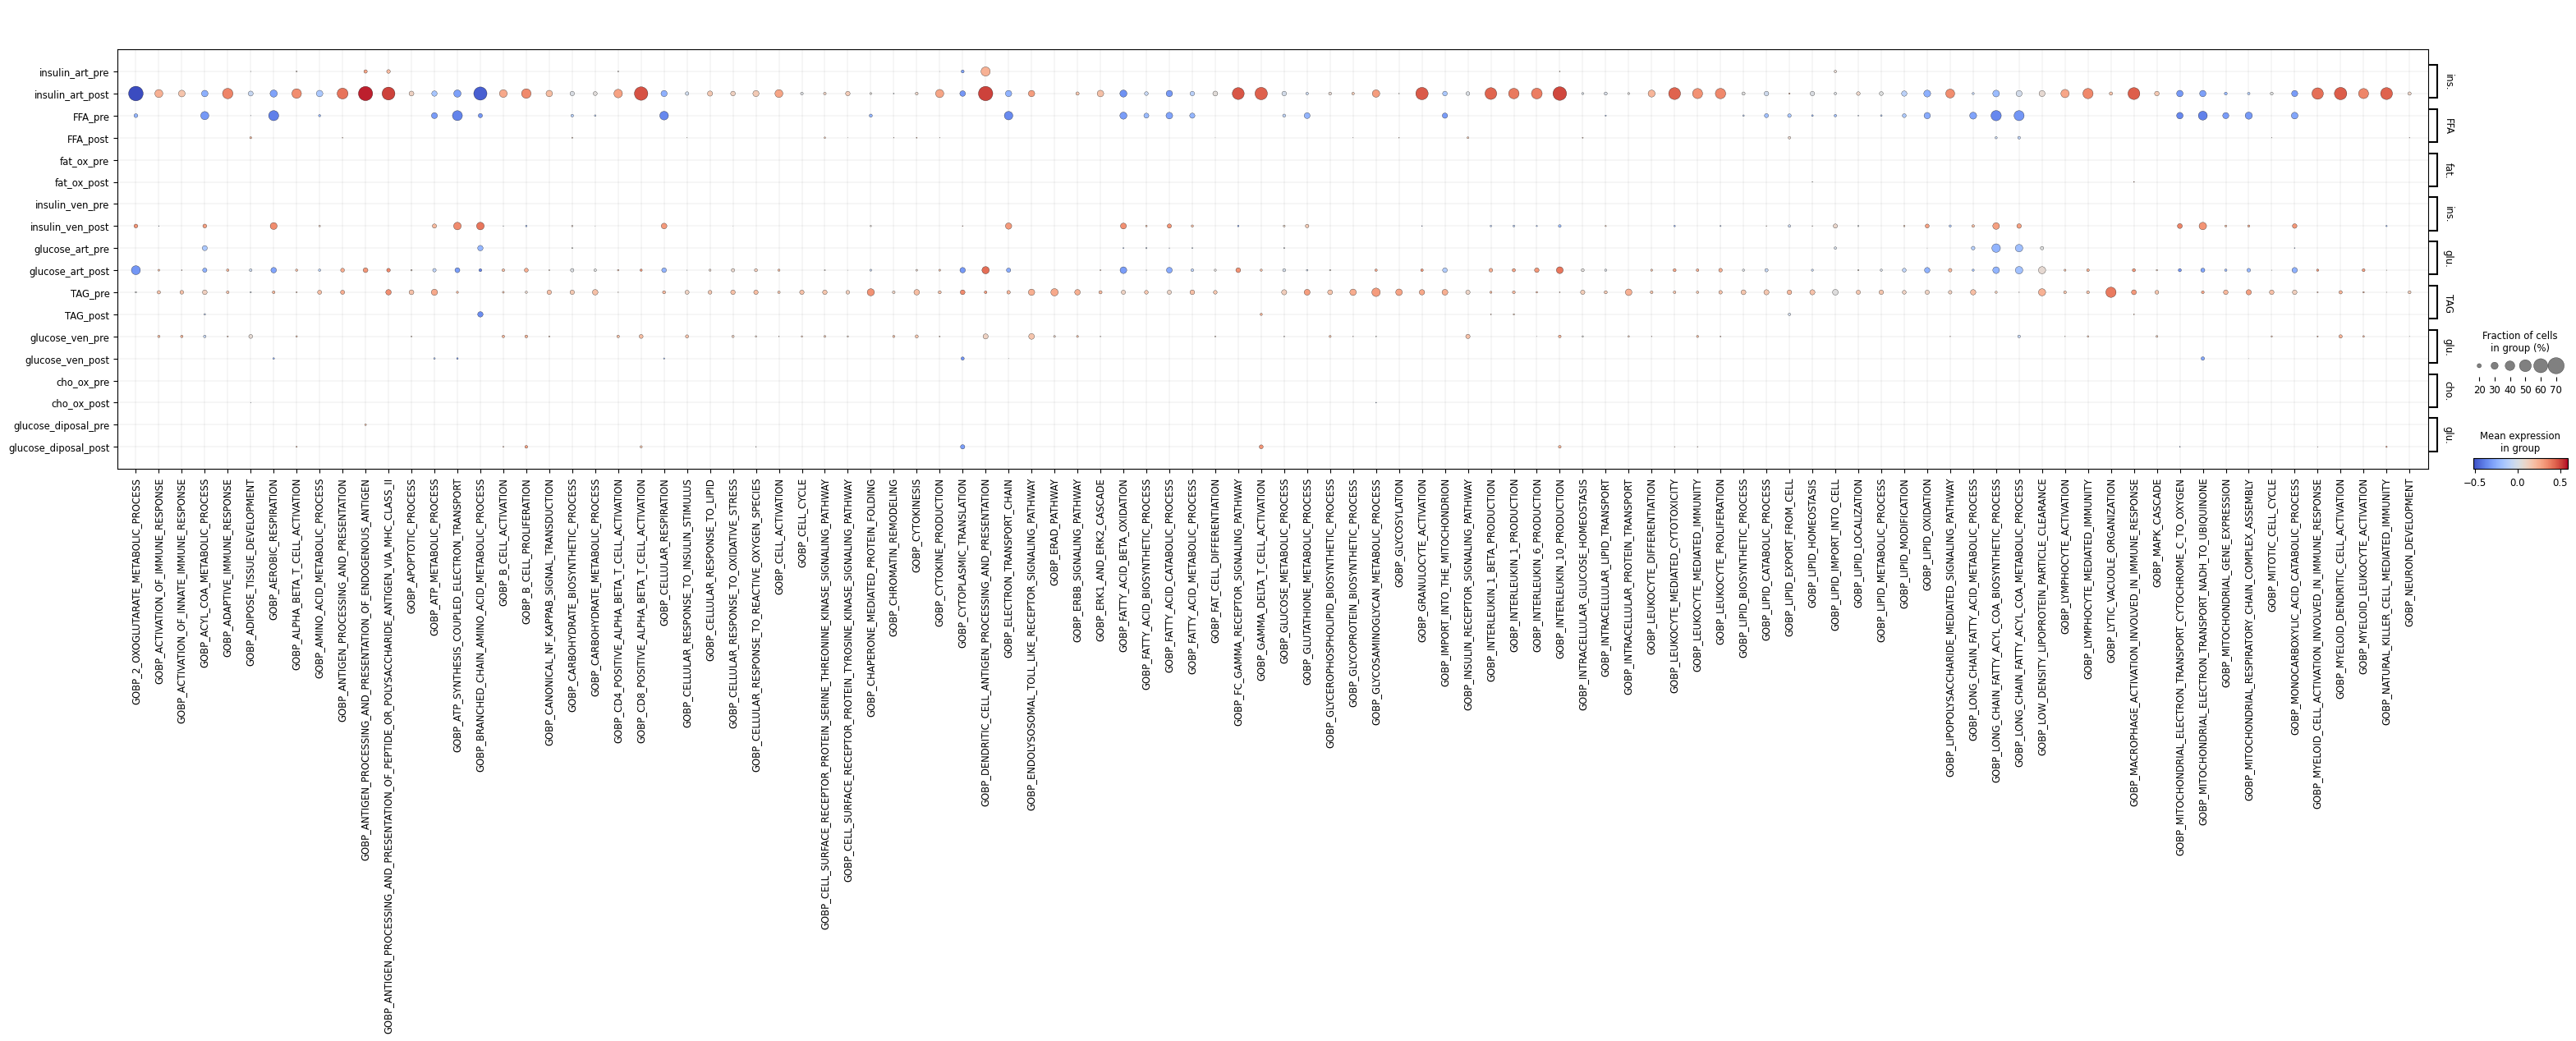

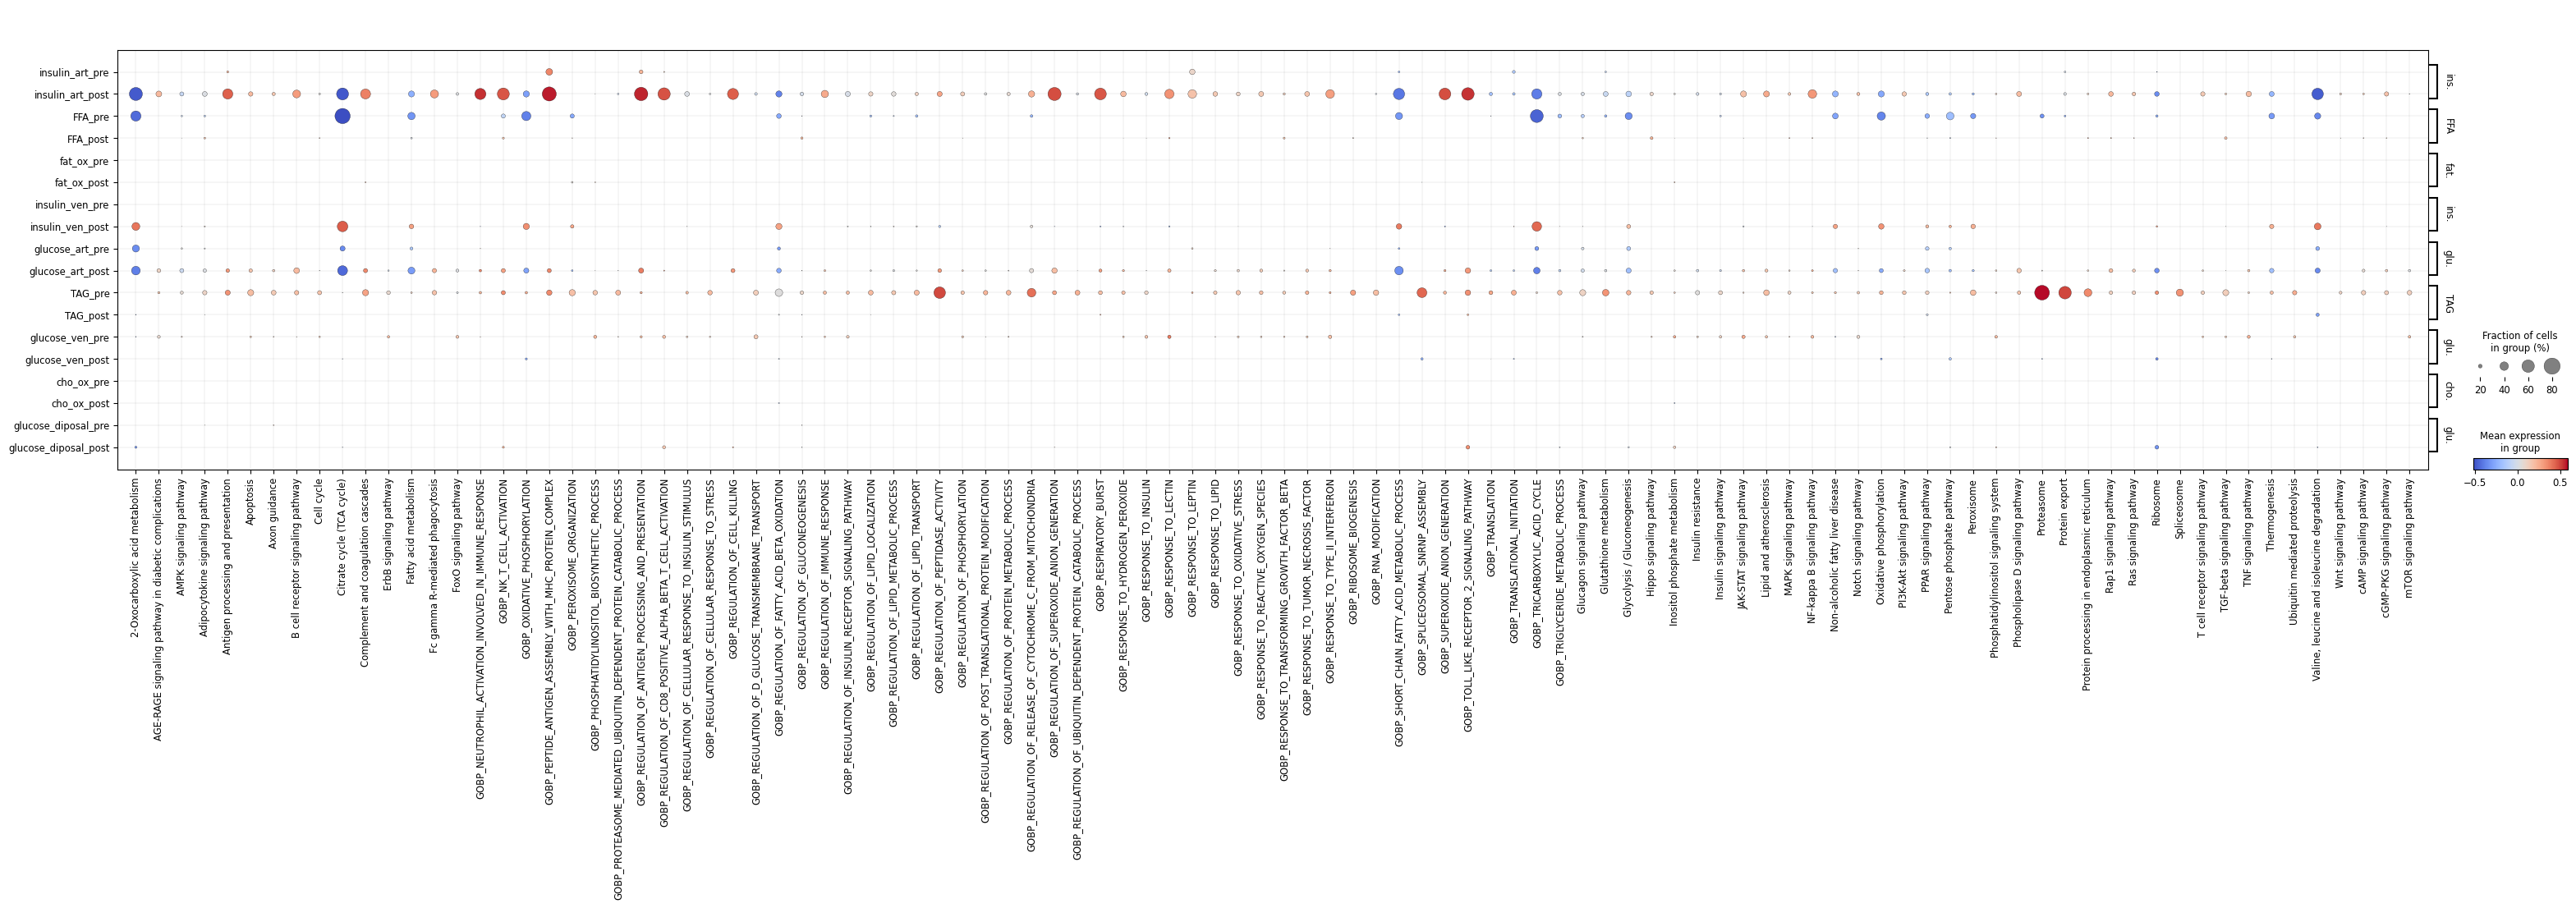

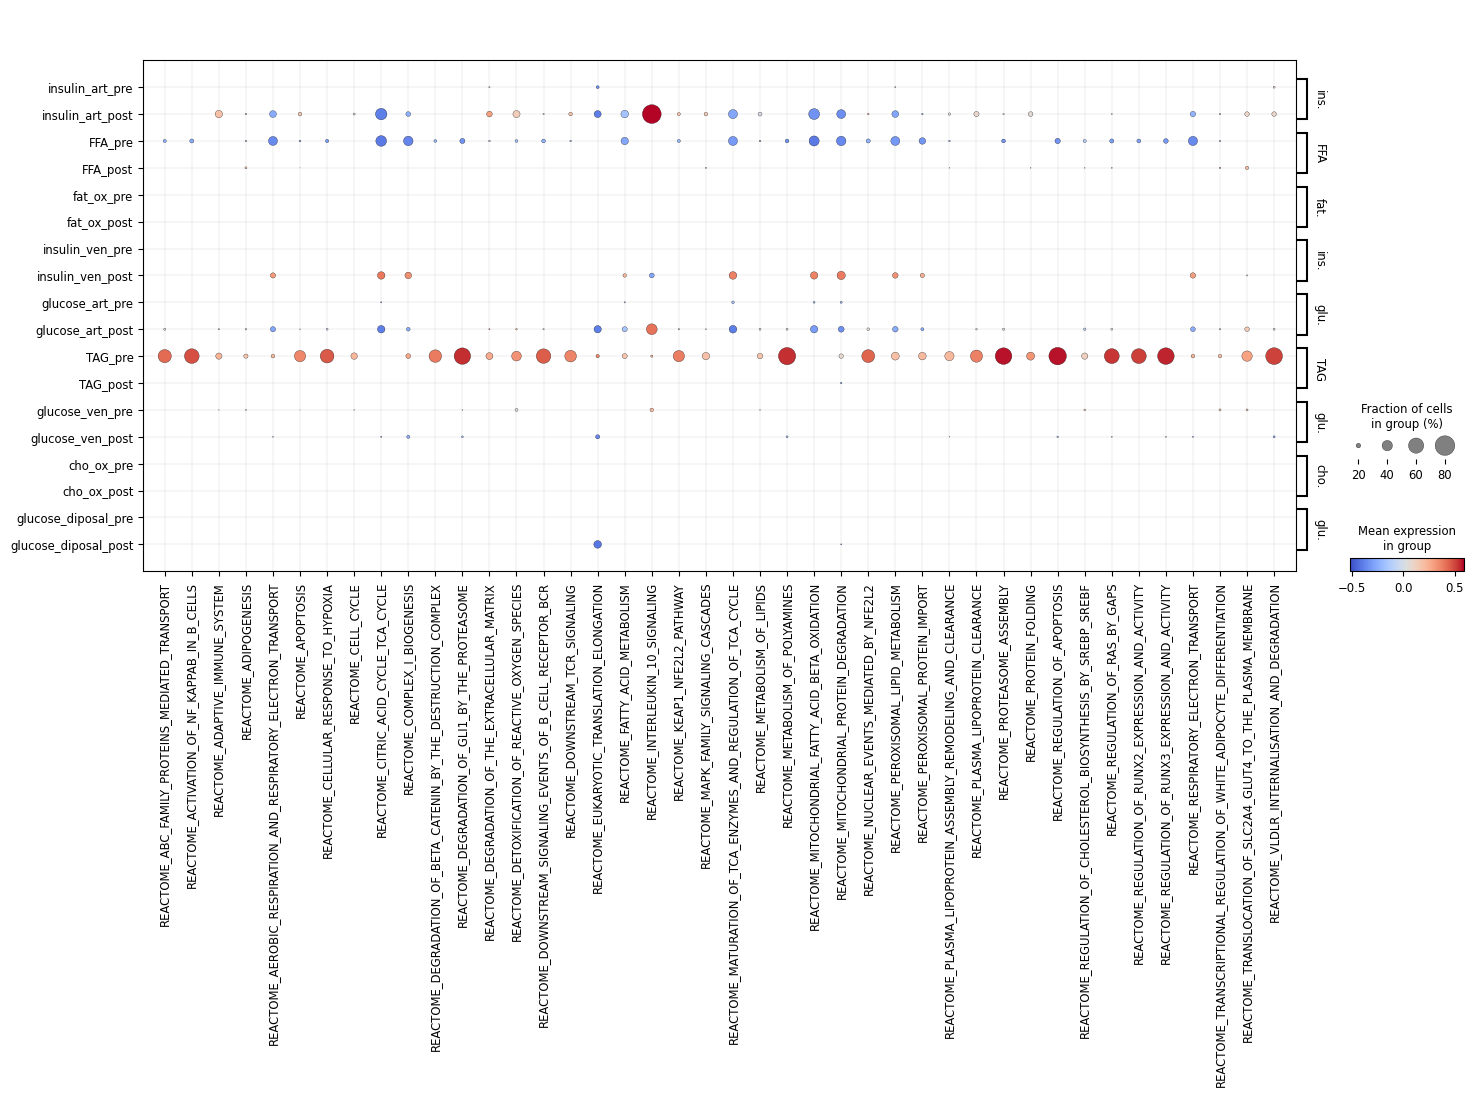

In [711]:
bs = 100
save_fig = False

adata = adata_hl

assert (adata.obs_names == percent_signifs_df.index).all()

for i in range(0, adata.shape[0], bs):
    p = dotplot(
        adata[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=np.nanmin(adata.X),
        vmax=np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=percent_signifs_df.loc[adata[i:(i + bs),:].obs_names,:],
        swap_axes=True,
        return_fig=True,
        dot_min=0.1,
        # dot_max=1
    ) #, dendrogram=True)
    
    p.grid=True
    p.group_cmaps = None
    p.make_figure()
    
    if save_fig:
        plt.savefig(f'figures_cors/all_{i}.png', bbox_inches='tight')
        plt.close()

In [712]:
adata.shape

(242, 18)

## top list

In [812]:
cors.keys()

dict_keys(['insulin_art', 'FFA', 'fat_ox', 'insulin_ven', 'glucose_art', 'insulin_AV', 'TAG', 'glucose_ven', 'cho_ox', 'glucose_AV', 'glucose_diposal'])

In [813]:
pheno = "glucose_AV"
tmp = "pre"

In [814]:
pheno_tmp = cors[pheno][tmp]
pheno_tmp_signif = pheno_tmp.loc[pheno_tmp.pvalue < 0.01,:]
pheno_tmp_signif.sort_values("pvalue").head(50)

,gene,pheno,r,pvalue,median_expr,ensembl_gene_id,converted_alias,name,description
10230,ENSG00000175344.19,glucose_AV,-0.741632,0.000182,0.360,ENSG00000175344,1139,CHRNA7,cholinergic receptor nicotinic alpha 7 subunit...
16616,ENSG00000287988.2,glucose_AV,-0.737832,0.000205,0.220,ENSG00000287988,None,None,None
11206,ENSG00000184906.12,glucose_AV,-0.737832,0.000205,0.220,ENSG00000184906,None,None,None
16528,ENSG00000286506.2,glucose_AV,-0.737832,0.000205,0.220,ENSG00000286506,None,None,None
2716,ENSG00000107099.18,glucose_AV,-0.728845,0.000267,10.925,ENSG00000107099,81704,DOCK8,dedicator of cytokinesis 8 [Source:HGNC Symbol...
13413,ENSG00000229619.6,glucose_AV,-0.706281,0.000500,5.845,ENSG00000229619,None,None,None
13222,ENSG00000226107.1,glucose_AV,-0.702772,0.000549,0.475,ENSG00000226107,None,None,None
16821,ENSG00000289616.3,glucose_AV,0.700752,0.000579,1.295,ENSG00000289616,None,None,None
17537,ENSG00000301360.1,glucose_AV,0.698007,0.000621,0.975,ENSG00000301360,None,None,None
2340,ENSG00000104267.10,glucose_AV,-0.682707,0.000910,4.825,ENSG00000104267,760,CA2,carbonic anhydrase 2 [Source:HGNC Symbol;Acc:H...


In [716]:
gene_id = "converted_alias"
pheno_tmp_signif.shape, pheno_tmp_signif[gene_id].isna().sum()

((355, 10), np.int64(89))

In [717]:
pheno_tmp_signif_ = pheno_tmp_signif.loc[~pheno_tmp_signif[gene_id].isna(),:]

In [719]:
pheno_tmp_genesets = {}

pheno_tmp_siginf_genes = set(pheno_tmp_signif_[gene_id])

for db, db_genesets in genesets.items():
    
    pheno_tmp_genesets[db] = {}
    
    for geneset_name, genes in db_genesets.pathways.items():
        intersection = pheno_tmp_siginf_genes.intersection(genes)
        if intersection:
            pheno_tmp_genesets[db][geneset_name] = len(intersection)/len(pheno_tmp_siginf_genes)

    pheno_tmp_genesets[db] = pd.DataFrame.from_dict(pheno_tmp_genesets[db], orient="index")

In [720]:
pheno_tmp_genesets["GOBP"].sort_values(0).tail(30)

,0
GOBP_SULFUR_COMPOUND_METABOLIC_PROCESS,0.105263
GOBP_INTRACELLULAR_TRANSPORT,0.109023
GOBP_LIPID_BIOSYNTHETIC_PROCESS,0.109023
GOBP_AEROBIC_RESPIRATION,0.112782
GOBP_PROTEIN_TRANSPORT,0.112782
GOBP_NUCLEOTIDE_METABOLIC_PROCESS,0.112782
GOBP_AMIDE_METABOLIC_PROCESS,0.112782
GOBP_RESPONSE_TO_OXYGEN_CONTAINING_COMPOUND,0.112782
GOBP_CELLULAR_RESPIRATION,0.116541
GOBP_FATTY_ACID_METABOLIC_PROCESS,0.116541


In [721]:
pheno_tmp_genesets["KEGG"].sort_values(0).tail(30)

,0
Biosynthesis of unsaturated fatty acids,0.018797
Glycerolipid metabolism,0.022556
Insulin resistance,0.022556
AMPK signaling pathway,0.022556
Calcium signaling pathway,0.022556
Ribosome,0.022556
Insulin signaling pathway,0.026316
2-Oxocarboxylic acid metabolism,0.026316
Peroxisome,0.030075
Pyruvate metabolism,0.030075


In [722]:
pheno_tmp_genesets["reactome"].sort_values(0).tail(30)

,0
REACTOME_FATTY_ACYL_COA_BIOSYNTHESIS,0.030075
REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,0.030075
REACTOME_HEMOSTASIS,0.033835
REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,0.033835
REACTOME_RNA_POLYMERASE_II_TRANSCRIPTION,0.033835
REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM,0.033835
REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE,0.037594
REACTOME_METABOLISM_OF_RNA,0.037594
REACTOME_VIRAL_INFECTION_PATHWAYS,0.037594
REACTOME_CELL_CYCLE,0.037594


In [723]:
len(pheno_tmp_siginf_genes), len(pheno_tmp_siginf_genes.intersection(all_genesets_genes))

(266, 266)

# Dotplot function

In [130]:
from scanpy._utils import _doc_params, _empty

In [131]:
from scanpy.plotting._anndata import _prepare_dataframe
from scanpy.plotting._baseplot_class import _var_groups

In [132]:
from scanpy.plotting import DotPlot
from scanpy._utils import _doc_params, _empty
from scanpy.plotting._utils import (
    _dk,
    check_colornorm,
    fix_kwds,
    make_grid_spec,
    savefig_or_show,
)
from matplotlib import colormaps, gridspec
from scanpy.plotting._anndata import (
    VarGroups,
    _plot_dendrogram,
    _plot_var_groups_brackets,
    _prepare_dataframe,
    _reorder_categories_after_dendrogram,
)


class DotPlot_(DotPlot):

    @staticmethod
    def _dotplot(  # noqa: PLR0912, PLR0913, PLR0915
        dot_size: pd.DataFrame,
        dot_color: pd.DataFrame,
        dot_ax,
        *,
        cmap,
        group_cmaps,
        color_on,
        dot_max: float | None,
        dot_min: float | None,
        standard_scale,
        smallest_dot: float,
        largest_dot: float,
        size_exponent: float,
        edge_color,
        edge_lw: float | None,
        grid: bool,
        x_padding: float,
        y_padding: float,
        vmin: float | None,
        vmax: float | None,
        vcenter: float | None,
        norm,
        are_axes_swapped: bool | None,
        **kwds,
    ):
        """Make a *dot plot* given two data frames.
    
        One containing the dot size and other containing the dot color.
        The indices and columns of the data frame are used to label the output image.
    
        The dots are plotted using :func:`matplotlib.pyplot.scatter`. Thus, additional
        arguments can be passed.
    
        Parameters
        ----------
        dot_size
            Data frame containing the dot_size.
        dot_color
            Data frame containing the dot_color, should have the same,
            shape, columns and indices as dot_size.
        dot_ax
            matplotlib axis
        cmap
        color_on
        dot_max
        dot_min
        standard_scale
        smallest_dot
        edge_color
        edge_lw
        grid
        x_padding
        y_padding
            See `style`
        kwds
            Are passed to :func:`matplotlib.pyplot.scatter`.
    
        Returns
        -------
        matplotlib.colors.Normalize, dot_min, dot_max
    
        """
        assert dot_size.shape == dot_color.shape, (
            f"please check that dot_size and dot_color dataframes have the same shape"
        )
        
        # assert list(dot_size.index) == list(dot_color.index), (
        #     f"please check that dot_size {list(dot_size.index)} and dot_color {list(dot_color.index)} dataframes have the same index"
        # )
        dot_size = dot_size.loc[dot_color.index, :]
    
        assert list(dot_size.columns) == list(dot_color.columns), (
            f"please check that the dot_size "
            f"and dot_color dataframes have the same columns"
        )
        match are_axes_swapped, standard_scale:
            case True, "group":
                group_axis = 1
            case True, "var":
                group_axis = 0
            case _, "group":
                group_axis = 0
            case _, "var":
                group_axis = 1
        if standard_scale is not None:
            dot_color = dot_color.sub(
                dot_color.min(axis=1 - group_axis), axis=group_axis
            )
            dot_color = dot_color.div(
                dot_color.max(axis=1 - group_axis), axis=group_axis
            ).fillna(0)
        # make scatter plot in which
        # x = var_names
        # y = groupby category
        # size = fraction
        # color = mean expression
    
        # +0.5 in y and x to set the dot center at 0.5 multiples
        # this facilitates dendrogram and totals alignment for
        # matrixplot, dotplot and stackec_violin using the same coordinates.
        y, x = np.indices(dot_color.shape)
        y = y.flatten() + 0.5
        x = x.flatten() + 0.5
        frac = dot_size.values.flatten()
        mean_flat = dot_color.values.flatten()
        cmap = colormaps.get_cmap(cmap)
        if dot_max is None:
            dot_max = np.ceil(max(frac) * 10) / 10
        elif dot_max < 0 or dot_max > 1:
            msg = "`dot_max` value has to be between 0 and 1"
            raise ValueError(msg)
        if dot_min is None:
            dot_min = 0
        elif dot_min < 0 or dot_min > 1:
            msg = "`dot_min` value has to be between 0 and 1"
            raise ValueError(msg)
    
        if dot_min != 0 or dot_max != 1:
            # clip frac between dot_min and  dot_max
            frac = np.clip(frac, dot_min, dot_max)
            old_range = dot_max - dot_min
            # re-scale frac between 0 and 1
            frac = (frac - dot_min) / old_range
    
        size = frac**size_exponent
        # rescale size to match smallest_dot and largest_dot
        size = size * (largest_dot - smallest_dot) + smallest_dot
        normalize = check_colornorm(vmin, vmax, vcenter, norm)
    
        if group_cmaps is not None:
            # Plotting logic for group-specific colormaps
            groups_iter = dot_color.columns if are_axes_swapped else dot_color.index
            n_vars = dot_color.shape[0] if are_axes_swapped else dot_color.shape[1]
            n_groups = len(groups_iter)
    
            # Here we loop through each group and plot it with its own cmap
            for group_idx, group_name in enumerate(groups_iter):
                group_cmap = group_cmaps[group_name]
                # Handle fallback case where group_cmap might be a string
                if isinstance(group_cmap, str):
                    group_cmap = colormaps.get_cmap(group_cmap)
    
                # Slice the flattened data arrays correctly depending on orientation
                if not are_axes_swapped:
                    # Slicing data for a whole row
                    indices = slice(group_idx * n_vars, (group_idx + 1) * n_vars)
                else:
                    # Slicing data for a whole column
                    indices = slice(group_idx, None, n_groups)
    
                x_group = x[indices]
                y_group = y[indices]
                size_group = size[indices]
                mean_group = mean_flat[indices]
    
                color = group_cmap(normalize(mean_group))
                kwds_scatter = fix_kwds(
                    kwds,
                    s=size_group,
                    color=color,
                    linewidth=edge_lw,
                    edgecolor=edge_color,
                )
                dot_ax.scatter(x_group, y_group, **kwds_scatter)
        elif color_on == "square":
            if edge_color is None:
                from seaborn.utils import relative_luminance
    
                # use either black or white for the edge color
                # depending on the luminance of the background
                # square color
                edge_color = []
                for color_value in cmap(normalize(mean_flat)):
                    lum = relative_luminance(color_value)
                    edge_color.append(".15" if lum > 0.408 else "w")
    
            edge_lw = 1.5 if edge_lw is None else edge_lw
    
            # first make a heatmap similar to `sc.pl.matrixplot`
            # (squares with the asigned colormap). Circles will be plotted
            # on top
            dot_ax.pcolor(dot_color.values, cmap=cmap, norm=normalize)
            for axis in ["top", "bottom", "left", "right"]:
                dot_ax.spines[axis].set_linewidth(1.5)
            # Create a temporary kwargs dict for this group's scatter call
            # to avoid modifying the original kwds dictionary within the loop.
            kwds_scatter = fix_kwds(
                kwds,
                s=size,
                linewidth=edge_lw,
                facecolor="none",
                edgecolor=edge_color,
            )
            dot_ax.scatter(x, y, **kwds_scatter)
        else:
            size = size.astype(np.float64)
            # print(y)
            # y += np.repeat(np.arange(int(y.shape[0]/2)), 2)
            # print(y)
            
            edge_color = "none" if edge_color is None else edge_color
            edge_lw = 0.0 if edge_lw is None else edge_lw
            color = cmap(normalize(mean_flat))
            kwds_scatter = fix_kwds(
                kwds,
                s=size,
                color=color,
                linewidth=edge_lw,
                edgecolor=edge_color,
            )
            dot_ax.scatter(x, y, **kwds_scatter)
    
        y_ticks = np.arange(dot_color.shape[0]) + 0.5
        dot_ax.set_yticks(y_ticks)
        dot_ax.set_yticklabels(
            [dot_color.index[idx] for idx, _ in enumerate(y_ticks)], minor=False
        )
    
        x_ticks = np.arange(dot_color.shape[1]) + 0.5
        dot_ax.set_xticks(x_ticks)
        dot_ax.set_xticklabels(
            [dot_color.columns[idx] for idx, _ in enumerate(x_ticks)],
            rotation=90,
            ha="center",
            minor=False,
        )
        dot_ax.tick_params(axis="both", labelsize="small")
        dot_ax.grid(visible=False)
    
        # to be consistent with the heatmap plot, is better to
        # invert the order of the y-axis, such that the first group is on
        # top
        dot_ax.set_ylim(dot_color.shape[0], 0)
        dot_ax.set_xlim(0, dot_color.shape[1])
    
        if color_on == "dot":
            # add padding to the x and y lims when the color is not in the square
            # default y range goes from 0.5 to num cols + 0.5
            # and default x range goes from 0.5 to num rows + 0.5, thus
            # the padding needs to be corrected.
            x_padding = x_padding - 0.5
            y_padding = y_padding - 0.5
            dot_ax.set_ylim(dot_color.shape[0] + y_padding, -y_padding)
    
            dot_ax.set_xlim(-x_padding, dot_color.shape[1] + x_padding)
    
        if grid:
            dot_ax.grid(visible=True, color="gray", linewidth=0.1)
            dot_ax.set_axisbelow(True)
    
        return normalize, dot_min, dot_max
    
    
    def _mainplot(self, ax):
        # work on a copy of the dataframes. This is to avoid changes
        # on the original data frames after repetitive calls to the
        # DotPlot object, for example once with swap_axes and other without
    
        _color_df = self.dot_color_df.copy()
        _size_df = self.dot_size_df.copy()
        if self.var_names_idx_order is not None:
            _color_df = _color_df.iloc[:, self.var_names_idx_order]
            _size_df = _size_df.iloc[:, self.var_names_idx_order]
    
        if self.categories_order is not None:
            _color_df = _color_df.loc[self.categories_order, :]
            _size_df = _size_df.loc[self.categories_order, :]
    
        if self.are_axes_swapped:
            _size_df = _size_df.T
            _color_df = _color_df.T
        self.cmap = self.kwds.pop("cmap", self.cmap)

        
        normalize, dot_min, dot_max = self._dotplot(
            _size_df,
            _color_df,
            ax,
            cmap=self.cmap,
            group_cmaps=self.group_cmaps,
            color_on=self.color_on,
            dot_max=self.dot_max,
            dot_min=self.dot_min,
            standard_scale=self.standard_scale,
            edge_color=self.dot_edge_color,
            edge_lw=self.dot_edge_lw,
            smallest_dot=self.smallest_dot,
            largest_dot=self.largest_dot,
            size_exponent=self.size_exponent,
            grid=self.grid,
            x_padding=self.plot_x_padding,
            y_padding=self.plot_y_padding,
            vmin=self.vboundnorm.vmin,
            vmax=self.vboundnorm.vmax,
            vcenter=self.vboundnorm.vcenter,
            norm=self.vboundnorm.norm,
            are_axes_swapped=self.are_axes_swapped,
            **self.kwds,
        )
    
        self.dot_min, self.dot_max = dot_min, dot_max
        return normalize
    
    def make_figure(self) -> None:  # noqa: PLR0912, PLR0915
        r"""Render the image but does not call :func:`matplotlib.pyplot.show`.
    
        Useful when several plots are put together into one figure.
    
        See Also
        --------
        `show()`: Renders and shows the plot.
        `savefig()`: Saves the plot.
    
        Examples
        --------
        >>> import scanpy as sc
        >>> import matplotlib.pyplot as plt
        >>> adata = sc.datasets.pbmc68k_reduced()
        >>> markers = ['C1QA', 'PSAP', 'CD79A', 'CD79B', 'CST3', 'LYZ']
        >>> fig, (ax0, ax1) = plt.subplots(1, 2)
        >>> sc.pl.MatrixPlot(adata, markers, groupby='bulk_labels', ax=ax0) \
        ...     .style(cmap='Blues', edge_color='none').make_figure()
        >>> sc.pl.DotPlot(adata, markers, groupby='bulk_labels', ax=ax1).make_figure()
    
        """
        category_height = self.DEFAULT_CATEGORY_HEIGHT
        category_width = self.DEFAULT_CATEGORY_WIDTH
    
        if self.height is None:
            mainplot_height = len(self.categories) * category_height
            mainplot_width = (
                len(self.var_names) * category_width + self.group_extra_size
            )
            if self.are_axes_swapped:
                mainplot_height, mainplot_width = mainplot_width, mainplot_height
    
            height = mainplot_height + 1  # +1 for labels
    
            # if the number of categories is small use
            # a larger height, otherwise the legends do not fit
            self.height = max([self.min_figure_height, height])
            self.width = mainplot_width + self.legends_width
        else:
            self.min_figure_height = self.height
            mainplot_height = self.height
    
            mainplot_width = self.width - (self.legends_width + self.group_extra_size)
    
        return_ax_dict = {}
        # define a layout of 1 rows x 2 columns
        #   first ax is for the main figure.
        #   second ax is to plot legends
        legends_width_spacer = 0.7 / self.width
    
        self.fig, gs = make_grid_spec(
            self.ax or (self.width, self.height),
            nrows=1,
            ncols=2,
            wspace=legends_width_spacer,
            width_ratios=[mainplot_width + self.group_extra_size, self.legends_width],
        )
    
        if self.var_groups:
            # add some space in case 'brackets' want to be plotted on top of the image
            if self.are_axes_swapped:
                var_groups_height = category_height
            else:
                var_groups_height = category_height / 2
    
        else:
            var_groups_height = 0
    
        mainplot_width = mainplot_width - self.group_extra_size
        spacer_height = self.height - var_groups_height - mainplot_height
        if not self.are_axes_swapped:
            height_ratios = [spacer_height, var_groups_height, mainplot_height]
            width_ratios = [mainplot_width, self.group_extra_size]
    
        else:
            height_ratios = [spacer_height, self.group_extra_size, mainplot_height]
            width_ratios = [mainplot_width, var_groups_height]
            # gridspec is the same but rows and columns are swapped
    
        if self.fig_title is not None and self.fig_title.strip() != "":
            # for the figure title use the ax that contains
            # all the main graphical elements (main plot, dendrogram etc)
            # otherwise the title may overlay with the figure.
            # also, this puts the title centered on the main figure and not
            # centered between the main figure and the legends
            _ax = self.fig.add_subplot(gs[0, 0])
            _ax.axis("off")
            _ax.set_title(self.fig_title)
    
        # the main plot is divided into three rows and two columns
        # first row is an spacer that is adjusted in case the
        #           legends need more height than the main plot
        # second row is for brackets (if needed),
        # third row is for mainplot and dendrogram/totals (legend goes in gs[0,1]
        # defined earlier)
        mainplot_gs = gridspec.GridSpecFromSubplotSpec(
            nrows=3,
            ncols=2,
            wspace=self.wspace,
            hspace=0.0,
            subplot_spec=gs[0, 0],
            width_ratios=width_ratios,
            height_ratios=height_ratios,
        )
        main_ax = self.fig.add_subplot(mainplot_gs[2, 0])
        return_ax_dict["mainplot_ax"] = main_ax
        if not self.are_axes_swapped:
            if self.plot_group_extra is not None:
                group_extra_ax = self.fig.add_subplot(mainplot_gs[2, 1], sharey=main_ax)
                group_extra_orientation = "right"
            if self.var_groups:
                gene_groups_ax = self.fig.add_subplot(mainplot_gs[1, 0], sharex=main_ax)
                var_group_orientation = "top"
        else:
            if self.plot_group_extra:
                group_extra_ax = self.fig.add_subplot(mainplot_gs[1, 0], sharex=main_ax)
                group_extra_orientation = "top"
            if self.var_groups:
                gene_groups_ax = self.fig.add_subplot(mainplot_gs[2, 1], sharey=main_ax)
                var_group_orientation = "right"
    
        if self.plot_group_extra is not None:
            if self.plot_group_extra["kind"] == "dendrogram":
                _plot_dendrogram(
                    group_extra_ax,
                    self.adata,
                    self.groupby,
                    dendrogram_key=self.plot_group_extra["dendrogram_key"],
                    ticks=self.plot_group_extra["dendrogram_ticks"],
                    orientation=group_extra_orientation,
                )
            if self.plot_group_extra["kind"] == "group_totals":
                self._plot_totals(group_extra_ax, group_extra_orientation)
    
            return_ax_dict["group_extra_ax"] = group_extra_ax
    
        # plot group legends on top or left of main_ax (if given)
        if self.var_groups:
            _plot_var_groups_brackets(
                gene_groups_ax,
                var_groups=self.var_groups,
                rotation=self.var_group_rotation,
                left_adjustment=0.2,
                right_adjustment=0.7,
                orientation=var_group_orientation,
                wide=True,
            )
            return_ax_dict["gene_group_ax"] = gene_groups_ax
    
        # plot the mainplot
        normalize = self._mainplot(main_ax)
    
        # code from pandas.plot in add_totals adds
        # minor ticks that need to be removed
        main_ax.yaxis.set_tick_params(which="minor", left=False, right=False)
        main_ax.xaxis.set_tick_params(which="minor", top=False, bottom=False, length=0)
        main_ax.set_zorder(100)
        if self.legends_width > 0:
            legend_ax = self.fig.add_subplot(gs[0, 1])
            self._plot_legend(legend_ax, return_ax_dict, normalize)
    
        self.ax_dict = return_ax_dict


def dotplot(  # noqa: PLR0913
    adata,
    var_names,
    groupby,
    *,
    use_raw: bool | None = None,
    log: bool = False,
    num_categories: int = 7,
    categories_order = None,
    expression_cutoff: float = 0.0,
    mean_only_expressed: bool = False,
    standard_scale = None,
    title: str | None = None,
    colorbar_title: str | None = DotPlot.DEFAULT_COLOR_LEGEND_TITLE,
    size_title: str | None = DotPlot.DEFAULT_SIZE_LEGEND_TITLE,
    figsize: tuple[float, float] | None = None,
    dendrogram: bool | str = False,
    gene_symbols: str | None = None,
    var_group_positions = None,
    var_group_labels = None,
    var_group_rotation: float | None = None,
    layer: str | None = None,
    swap_axes: bool | None = False,
    dot_color_df: pd.DataFrame | None = None,
    show: bool | None = None,
    save: str | bool | None = None,
    ax = None,
    return_fig: bool | None = False,
    vmin: float | None = None,
    vmax: float | None = None,
    vcenter: float | None = None,
    norm = None,
    # Style parameters
    cmap = DotPlot.DEFAULT_COLORMAP,
    dot_max: float | None = DotPlot.DEFAULT_DOT_MAX,
    dot_min: float | None = DotPlot.DEFAULT_DOT_MIN,
    smallest_dot: float = DotPlot.DEFAULT_SMALLEST_DOT,
    **kwds,
) -> DotPlot | dict | None:
    r"""Make a *dot plot* of the expression values of `var_names`.

    For each var_name and each `groupby` category a dot is plotted.
    Each dot represents two values: mean expression within each category
    (visualized by color) and fraction of cells expressing the `var_name` in the
    category (visualized by the size of the dot). If `groupby` is not given,
    the dotplot assumes that all data belongs to a single category.

    .. note::
       A gene is considered expressed if the expression value in the `adata` (or
       `adata.raw`) is above the specified threshold which is zero by default.

    An example of dotplot usage is to visualize, for multiple marker genes,
    the mean value and the percentage of cells expressing the gene
    across  multiple clusters.

    This function provides a convenient interface to the :class:`~scanpy.pl.DotPlot`
    class. If you need more flexibility, you should use :class:`~scanpy.pl.DotPlot`
    directly.

    Parameters
    ----------
    {common_plot_args}
    {groupby_plots_args}
    size_title
        Title for the size legend. New line character (\n) can be used.
    expression_cutoff
        Expression cutoff that is used for binarizing the gene expression and
        determining the fraction of cells expressing given genes. A gene is
        expressed only if the expression value is greater than this threshold.
    mean_only_expressed
        If True, gene expression is averaged only over the cells
        expressing the given genes.
    dot_max
        If ``None``, the maximum dot size is set to the maximum fraction value found
        (e.g. 0.6). If given, the value should be a number between 0 and 1.
        All fractions larger than dot_max are clipped to this value.
    dot_min
        If ``None``, the minimum dot size is set to 0. If given,
        the value should be a number between 0 and 1.
        All fractions smaller than dot_min are clipped to this value.
    smallest_dot
        All expression levels with `dot_min` are plotted with this size.
    {show_save_ax}
    {vminmax}
    kwds
        Are passed to :func:`matplotlib.pyplot.scatter`.

    Returns
    -------
    If `return_fig` is `True`, returns a :class:`~scanpy.pl.DotPlot` object,
    else if `show` is false, return axes dict

    See Also
    --------
    :class:`~scanpy.pl.DotPlot`: The DotPlot class can be used to to control
        several visual parameters not available in this function.
    :func:`~scanpy.pl.rank_genes_groups_dotplot`: to plot marker genes
        identified using the :func:`~scanpy.tl.rank_genes_groups` function.

    Examples
    --------
    Create a dot plot using the given markers and the PBMC example dataset grouped by
    the category 'bulk_labels'.

    .. plot::
        :context: close-figs

        import scanpy as sc
        adata = sc.datasets.pbmc68k_reduced()
        markers = ['C1QA', 'PSAP', 'CD79A', 'CD79B', 'CST3', 'LYZ']
        sc.pl.dotplot(adata, markers, groupby='bulk_labels', dendrogram=True)

    Using var_names as dict:

    .. plot::
        :context: close-figs

        markers = {{'T-cell': 'CD3D', 'B-cell': 'CD79A', 'myeloid': 'CST3'}}
        sc.pl.dotplot(adata, markers, groupby='bulk_labels', dendrogram=True)

    Get DotPlot object for fine tuning

    .. plot::
        :context: close-figs

        dp = sc.pl.dotplot(adata, markers, 'bulk_labels', return_fig=True)
        dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).show()

    The axes used can be obtained using the get_axes() method

    .. code-block:: python

        axes_dict = dp.get_axes()
        print(axes_dict)

    """
    # backwards compatibility: previous version of dotplot used `color_map`
    # instead of `cmap`
    cmap = kwds.pop("color_map", cmap)

    dp = DotPlot_(
        adata,
        var_names,
        groupby,
        use_raw=use_raw,
        log=log,
        num_categories=num_categories,
        categories_order=categories_order,
        expression_cutoff=expression_cutoff,
        mean_only_expressed=mean_only_expressed,
        standard_scale=standard_scale,
        title=title,
        figsize=figsize,
        gene_symbols=gene_symbols,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        var_group_rotation=var_group_rotation,
        layer=layer,
        dot_color_df=dot_color_df,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        vcenter=vcenter,
        norm=norm,
        **kwds,
    )

    if dendrogram:
        dp.add_dendrogram(dendrogram_key=_dk(dendrogram))
    if swap_axes:
        dp.swap_axes()

    dp = dp.style(
        cmap=cmap,
        dot_max=dot_max,
        dot_min=dot_min,
        smallest_dot=smallest_dot,
        dot_edge_lw=kwds.pop("linewidth", _empty),
    ).legend(colorbar_title=colorbar_title, size_title=size_title)

    if return_fig:
        return dp
    else:
        dp.make_figure()
        savefig_or_show(DotPlot.DEFAULT_SAVE_PREFIX, show=show, save=save)
        # show = settings.autoshow if show is None else show
        # if not show:
            # return dp.get_axes()